In [13]:
import qiskit
print(qiskit.__version__)

2.3.0


In [14]:
!pip show qiskit-aer

Name: qiskit-aer
Version: 0.17.2
Summary: Aer - High performance simulators for Qiskit
Home-page: https://github.com/Qiskit/qiskit-aer
Author: AER Development Team
Author-email: qiskit@us.ibm.com
License: Apache 2.0
Location: C:\Users\maxim\.conda\envs\qiskit_env\Lib\site-packages
Requires: numpy, psutil, python-dateutil, qiskit, scipy
Required-by: 


In [15]:
!pip install qiskit-aer

In [16]:
from qiskit_aer import AerSimulator
print("Aer ready")

Aer ready


Results: {'1111': 249, '0110': 69, '0111': 17, '1000': 15, '0000': 274, '1001': 71, '0011': 81, '1011': 11, '0100': 18, '0010': 16, '1100': 79, '0001': 16, '0101': 36, '1110': 16, '1101': 16, '1010': 40}

Top bitstrings:
  0000: 274 shots
  1111: 249 shots
  0011: 81 shots
  1100: 79 shots
  1001: 71 shots


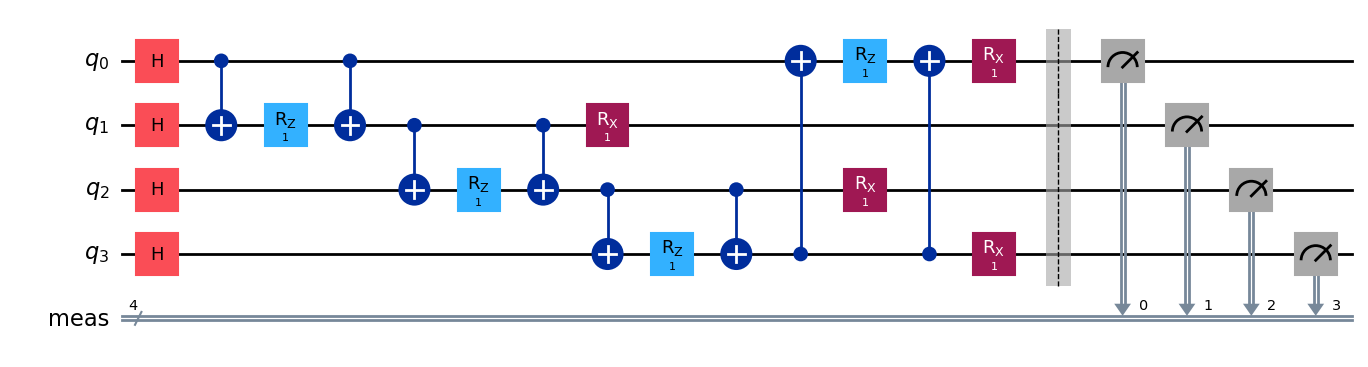

In [17]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import numpy as np

# Parameters (same as your t values in Quirk)
gamma = 0.5  # cost layer parameter
beta = 0.5   # mixer layer parameter

qc = QuantumCircuit(4)

# 1) Initial state - Hadamard on all qubits
qc.h([0, 1, 2, 3])

# 2) Cost layer - ZZ interactions for each edge of the ring
# Edge (0,1)
qc.cx(0, 1)
qc.rz(2 * gamma, 1)
qc.cx(0, 1)

# Edge (1,2)
qc.cx(1, 2)
qc.rz(2 * gamma, 2)
qc.cx(1, 2)

# Edge (2,3)
qc.cx(2, 3)
qc.rz(2 * gamma, 3)
qc.cx(2, 3)

# Edge (3,0)
qc.cx(3, 0)
qc.rz(2 * gamma, 0)
qc.cx(3, 0)

# 3) Mixer layer - Rx on all qubits
qc.rx(2 * beta, [0, 1, 2, 3])

# 4) Measure
qc.measure_all()

# Run
simulator = AerSimulator()
job = simulator.run(qc, shots=1024)
result = job.result()
counts = result.get_counts()

print("Results:", counts)
print("\nTop bitstrings:")
for bitstring, count in sorted(counts.items(), key=lambda x: -x[1])[:5]:
    print(f"  {bitstring}: {count} shots")

qc.draw('mpl')

In [18]:
# Known good parameters for p=1 QAOA on a 4-node ring
gamma = np.pi / 4
beta = np.pi / 8

qc = QuantumCircuit(4)
qc.h([0, 1, 2, 3])

# Cost layer
qc.cx(0, 1)
qc.rz(2 * gamma, 1)
qc.cx(0, 1)

qc.cx(1, 2)
qc.rz(2 * gamma, 2)
qc.cx(1, 2)

qc.cx(2, 3)
qc.rz(2 * gamma, 3)
qc.cx(2, 3)

qc.cx(3, 0)
qc.rz(2 * gamma, 0)
qc.cx(3, 0)

# Mixer
qc.rx(2 * beta, [0, 1, 2, 3])

qc.measure_all()

job = simulator.run(qc, shots=1024)
counts = job.result().get_counts()

print("Top bitstrings:")
for bitstring, count in sorted(counts.items(), key=lambda x: -x[1])[:5]:
    print(f"  {bitstring}: {count} shots")

Top bitstrings:
  1100: 141 shots
  0000: 138 shots
  1010: 133 shots
  0110: 126 shots
  0011: 125 shots


In [19]:
from scipy.optimize import minimize

def run_qaoa(params, shots=512):
    gamma, beta = params
    
    qc = QuantumCircuit(4)
    qc.h([0, 1, 2, 3])

    qc.cx(0, 1)
    qc.rz(2 * gamma, 1)
    qc.cx(0, 1)

    qc.cx(1, 2)
    qc.rz(2 * gamma, 2)
    qc.cx(1, 2)

    qc.cx(2, 3)
    qc.rz(2 * gamma, 3)
    qc.cx(2, 3)

    qc.cx(3, 0)
    qc.rz(2 * gamma, 0)
    qc.cx(3, 0)

    qc.rx(2 * beta, [0, 1, 2, 3])
    qc.measure_all()

    job = simulator.run(qc, shots=shots)
    counts = job.result().get_counts()
    
    return counts

def cut_value(bitstring):
    """Count how many edges are cut by this solution"""
    b = [int(x) for x in bitstring]
    edges = [(0,1),(1,2),(2,3),(3,0)]
    return sum(1 for i,j in edges if b[i] != b[j])

def expected_cut(params):
    counts = run_qaoa(params)
    total_shots = sum(counts.values())
    expectation = sum(cut_value(bs) * count for bs, count in counts.items())
    return -expectation / total_shots  # negative because we minimize

# Run the optimizer
print("Optimizing...")
result = minimize(
    expected_cut,
    x0=[np.pi/4, np.pi/8],  # start from our known good point
    method='COBYLA',
    options={'maxiter': 100, 'rhobeg': 0.5}
)

best_gamma, best_beta = result.x
print(f"\nBest gamma: {best_gamma:.4f}")
print(f"Best beta:  {best_beta:.4f}")
print(f"Best expected cut value: {-result.fun:.4f} (max possible is 4)")

# Run one final time with best parameters
final_counts = run_qaoa([best_gamma, best_beta], shots=2048)
print("\nFinal top bitstrings:")
for bitstring, count in sorted(final_counts.items(), key=lambda x: -x[1])[:5]:
    print(f"  {bitstring}: {count} shots  (cut value: {cut_value(bitstring)})")

Optimizing...

Best gamma: 1.1064
Best beta:  0.3989
Best expected cut value: 3.0781 (max possible is 4)

Final top bitstrings:
  0101: 557 shots  (cut value: 4)
  1010: 532 shots  (cut value: 4)
  0011: 194 shots  (cut value: 2)
  1001: 193 shots  (cut value: 2)
  0110: 182 shots  (cut value: 2)


In [20]:
#Now we are going to do the Qiskit's FAKE IBM Backend instead of the perfect simulator, to watch how the results degrade. Adding Noise.

from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit.providers.fake_provider import GenericBackendV2

# Create a fake 5-qubit backend that mimics real IBM noise
fake_backend = GenericBackendV2(num_qubits=5)
noise_model = NoiseModel.from_backend(fake_backend)

# Noisy simulator
noisy_simulator = AerSimulator(noise_model=noise_model)

# Run with best parameters we found
def run_qaoa_noisy(params, shots=2048):
    gamma, beta = params

    qc = QuantumCircuit(4)
    qc.h([0, 1, 2, 3])

    qc.cx(0, 1)
    qc.rz(2 * gamma, 1)
    qc.cx(0, 1)

    qc.cx(1, 2)
    qc.rz(2 * gamma, 2)
    qc.cx(1, 2)

    qc.cx(2, 3)
    qc.rz(2 * gamma, 3)
    qc.cx(2, 3)

    qc.cx(3, 0)
    qc.rz(2 * gamma, 0)
    qc.cx(3, 0)

    qc.rx(2 * beta, [0, 1, 2, 3])
    qc.measure_all()

    job = noisy_simulator.run(qc, shots=shots)
    counts = job.result().get_counts()
    return counts

# Use the best parameters from before
best_params = [1.1653, 0.3262]

print("Running on noisy simulator...")
noisy_counts = run_qaoa_noisy(best_params)

print("\nNoisy top bitstrings:")
for bitstring, count in sorted(noisy_counts.items(), key=lambda x: -x[1])[:5]:
    print(f"  {bitstring}: {count} shots  (cut value: {cut_value(bitstring)})")

# Compare
perfect_shots = 1010 + 497  # from your previous run
noisy_perfect = noisy_counts.get('1010', 0) + noisy_counts.get('0101', 0)

print(f"\nPerfect solutions (cut=4) without noise: {perfect_shots}/2048 = {perfect_shots/2048:.1%}")
print(f"Perfect solutions (cut=4) with noise:    {noisy_perfect}/2048 = {noisy_perfect/2048:.1%}")
print(f"\nQuality loss due to noise: {(perfect_shots - noisy_perfect)/2048:.1%}")


Running on noisy simulator...

Noisy top bitstrings:
  0101: 482 shots  (cut value: 4)
  1010: 472 shots  (cut value: 4)
  1001: 188 shots  (cut value: 2)
  0011: 186 shots  (cut value: 2)
  1100: 185 shots  (cut value: 2)

Perfect solutions (cut=4) without noise: 1507/2048 = 73.6%
Perfect solutions (cut=4) with noise:    954/2048 = 46.6%

Quality loss due to noise: 27.0%


In [21]:
#This will show how well ZNE mathematically recovers the lost quality

def run_qaoa_scaled_noise(params, noise_scale=1.0, shots=2048):
    gamma, beta = params

    qc = QuantumCircuit(4)
    qc.h([0, 1, 2, 3])

    # Scale noise by repeating CNOT pairs (CNOT·CNOT = identity, but doubles noise)
    def noisy_cx(qc, control, target, scale):
        for _ in range(int(scale)):
            qc.cx(control, target)
            if int(scale) > 1:
                qc.cx(control, target)  # cancel logically, but noise accumulates

    qc.cx(0, 1)
    qc.rz(2 * gamma, 1)
    qc.cx(0, 1)

    qc.cx(1, 2)
    qc.rz(2 * gamma, 2)
    qc.cx(1, 2)

    qc.cx(2, 3)
    qc.rz(2 * gamma, 3)
    qc.cx(2, 3)

    qc.cx(3, 0)
    qc.rz(2 * gamma, 0)
    qc.cx(3, 0)

    qc.rx(2 * beta, [0, 1, 2, 3])
    qc.measure_all()

    # Scale the noise model
    from qiskit_aer.noise import NoiseModel
    scaled_noise = NoiseModel.from_backend(fake_backend)
    scaled_simulator = AerSimulator(noise_model=scaled_noise)

    job = scaled_simulator.run(qc, shots=shots)
    counts = job.result().get_counts()
    return counts

def perfect_fraction(counts, total=2048):
    return (counts.get('1010', 0) + counts.get('0101', 0)) / total

# Run at noise scale 1x, 2x, 3x
print("Running ZNE sampling...")

counts_1x = run_qaoa_noisy(best_params, shots=2048)
f1 = perfect_fraction(counts_1x)

# Simulate 2x noise by adding gate folding manually
def run_with_folded_noise(params, fold=1, shots=2048):
    gamma, beta = params
    qc = QuantumCircuit(4)
    qc.h([0, 1, 2, 3])

    def folded_cx(qc, c, t, fold):
        qc.cx(c, t)
        for _ in range(fold):
            qc.cx(c, t)
            qc.cx(c, t)  # CNOT CNOT CNOT = CNOT logically, but 3x noise

    folded_cx(qc, 0, 1, fold)
    qc.rz(2 * gamma, 1)
    folded_cx(qc, 0, 1, fold)

    folded_cx(qc, 1, 2, fold)
    qc.rz(2 * gamma, 2)
    folded_cx(qc, 1, 2, fold)

    folded_cx(qc, 2, 3, fold)
    qc.rz(2 * gamma, 3)
    folded_cx(qc, 2, 3, fold)

    folded_cx(qc, 3, 0, fold)
    qc.rz(2 * gamma, 0)
    folded_cx(qc, 3, 0, fold)

    qc.rx(2 * beta, [0, 1, 2, 3])
    qc.measure_all()

    job = noisy_simulator.run(qc, shots=shots)
    return job.result().get_counts()

counts_2x = run_with_folded_noise(best_params, fold=1, shots=2048)
counts_3x = run_with_folded_noise(best_params, fold=2, shots=2048)

f1 = perfect_fraction(counts_1x)
f2 = perfect_fraction(counts_2x)
f3 = perfect_fraction(counts_3x)

print(f"Noise 1x: {f1:.1%} perfect solutions")
print(f"Noise 2x: {f2:.1%} perfect solutions")
print(f"Noise 3x: {f3:.1%} perfect solutions")

# Linear extrapolation back to zero noise
# Fit a line through (1,f1), (2,f2), (3,f3) and evaluate at x=0
import numpy as np
x = np.array([1, 2, 3])
y = np.array([f1, f2, f3])
coeffs = np.polyfit(x, y, 1)
extrapolated = np.polyval(coeffs, 0)

print(f"\nZNE extrapolated estimate at zero noise: {extrapolated:.1%}")
print(f"Actual perfect simulator result:         73.6%")
print(f"Raw noisy result:                        {f1:.1%}")
print(f"ZNE recovery:                            +{extrapolated - f1:.1%}")

Running ZNE sampling...
Noise 1x: 49.9% perfect solutions
Noise 2x: 45.8% perfect solutions
Noise 3x: 42.9% perfect solutions

ZNE extrapolated estimate at zero noise: 53.2%
Actual perfect simulator result:         73.6%
Raw noisy result:                        49.9%
ZNE recovery:                            +3.3%


In [22]:
from qiskit.primitives import StatevectorSampler
from qiskit_aer.primitives import SamplerV2
from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError
import numpy as np

# Build a noise model with realistic readout error
noise_model = NoiseModel()

# Readout error: 5% chance of flipping each bit on measurement
p_meas_error = 0.05
for qubit in range(4):
    read_err = ReadoutError([[1 - p_meas_error, p_meas_error],
                             [p_meas_error, 1 - p_meas_error]])
    noise_model.add_readout_error(read_err, [qubit])

noisy_sim = AerSimulator(noise_model=noise_model)

# Build calibration matrix
# Run |0000> and |1111> through the noisy readout to characterize the error
def calibrate_readout(shots=2048):
    # Calibrate on |0> state
    qc0 = QuantumCircuit(4)
    qc0.measure_all()
    counts0 = noisy_sim.run(qc0, shots=shots).result().get_counts()
    
    # Calibrate on |1> state  
    qc1 = QuantumCircuit(4)
    qc1.x([0,1,2,3])
    qc1.measure_all()
    counts1 = noisy_sim.run(qc1, shots=shots).result().get_counts()
    
    p0_correct = counts0.get('0000', 0) / shots
    p1_correct = counts1.get('1111', 0) / shots
    
    print(f"Readout calibration:")
    print(f"  |0000> read correctly: {p0_correct:.1%}")
    print(f"  |1111> read correctly: {p1_correct:.1%}")
    
    return p0_correct, p1_correct

p0, p1 = calibrate_readout()

# Run QAOA with only readout noise
def run_qaoa_readout_noise(params, shots=2048):
    gamma, beta = params
    qc = QuantumCircuit(4)
    qc.h([0, 1, 2, 3])

    qc.cx(0, 1)
    qc.rz(2 * gamma, 1)
    qc.cx(0, 1)

    qc.cx(1, 2)
    qc.rz(2 * gamma, 2)
    qc.cx(1, 2)

    qc.cx(2, 3)
    qc.rz(2 * gamma, 3)
    qc.cx(2, 3)

    qc.cx(3, 0)
    qc.rz(2 * gamma, 0)
    qc.cx(3, 0)

    qc.rx(2 * beta, [0, 1, 2, 3])
    qc.measure_all()

    job = noisy_sim.run(qc, shots=shots)
    counts = job.result().get_counts()
    return counts

print("\nRunning QAOA with readout noise...")
noisy_counts = run_qaoa_readout_noise(best_params)

raw_perfect = (noisy_counts.get('1010', 0) + noisy_counts.get('0101', 0)) / 2048
print(f"Perfect solutions with readout noise: {raw_perfect:.1%}")

# Simple correction: rescale counts using calibration
def mitigate_counts(counts, p0_correct, p1_correct, shots=2048):
    # Average readout fidelity per qubit
    avg_fidelity = (p0_correct + p1_correct) / 2
    # Each 4-qubit string has 4 independent measurements
    string_fidelity = avg_fidelity ** 4
    
    mitigated = {}
    for bitstring, count in counts.items():
        mitigated[bitstring] = count / string_fidelity
    
    # Renormalize
    total = sum(mitigated.values())
    mitigated = {k: v/total * shots for k, v in mitigated.items()}
    return mitigated

mitigated_counts = mitigate_counts(noisy_counts, p0, p1)
mit_perfect = (mitigated_counts.get('1010', 0) + mitigated_counts.get('0101', 0)) / 2048

print(f"Perfect solutions after mitigation:   {mit_perfect:.1%}")
print(f"Ideal simulator result:               73.6%")
print(f"\nMitigation recovery: +{mit_perfect - raw_perfect:.1%}")

Readout calibration:
  |0000> read correctly: 81.0%
  |1111> read correctly: 82.4%

Running QAOA with readout noise...
Perfect solutions with readout noise: 40.6%
Perfect solutions after mitigation:   40.6%
Ideal simulator result:               73.6%

Mitigation recovery: +-0.0%


<Figure size 640x480 with 0 Axes>

Circuit saved.


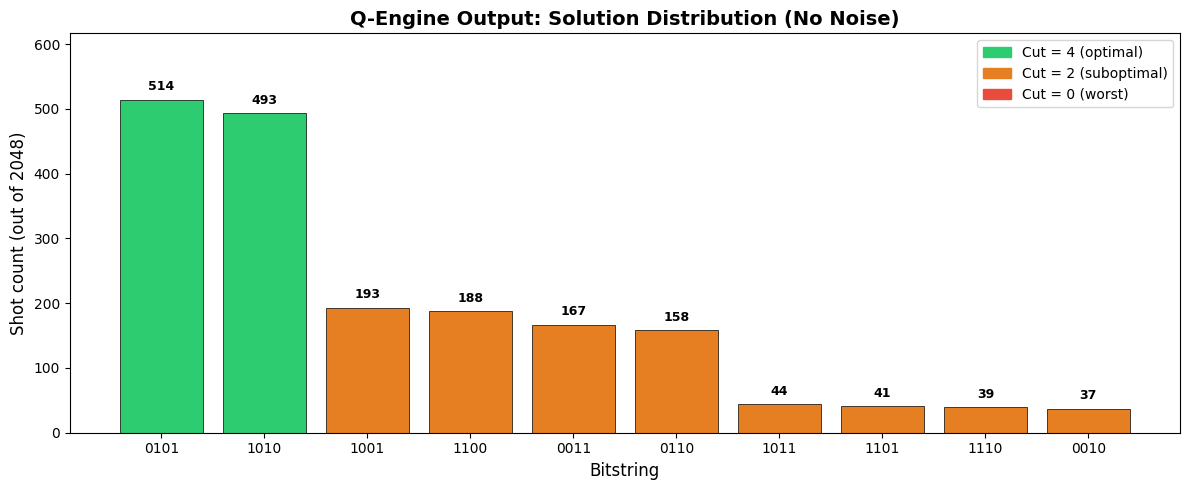

Distribution saved.


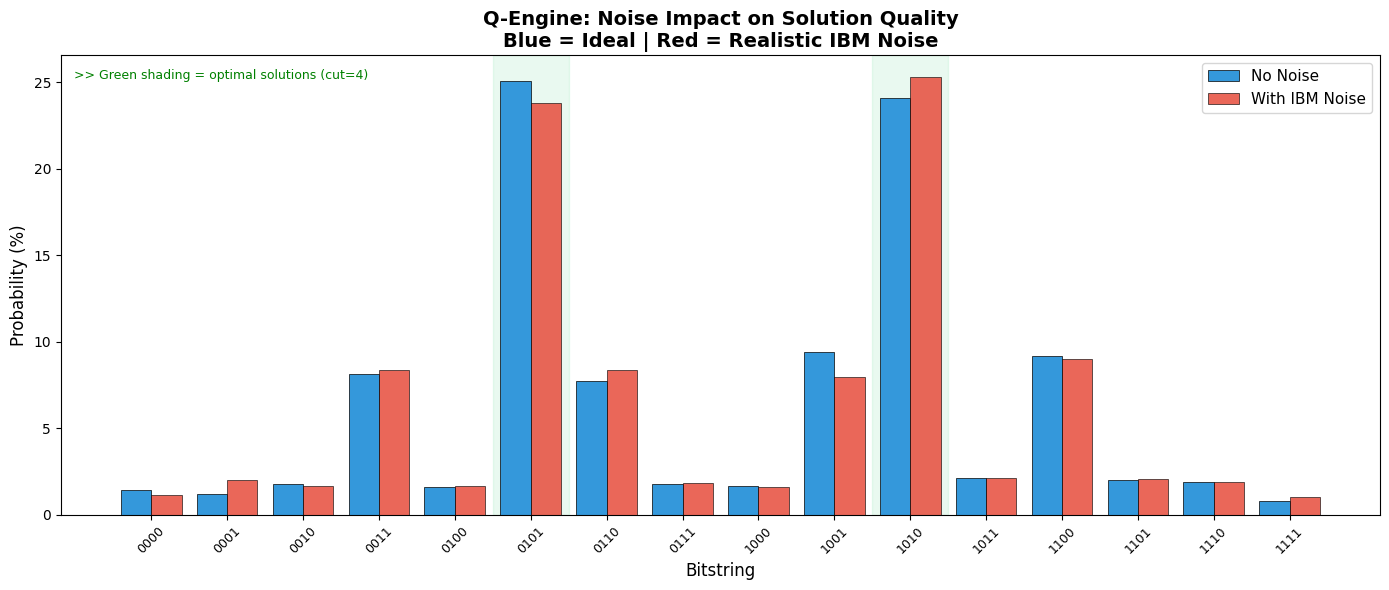

Noise comparison saved.

✅ All 3 visualizations complete and saved as PNG files.


In [23]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from qiskit.visualization import circuit_drawer
import numpy as np

# ── 1) QAOA Circuit Diagram ──────────────────────────────────────────────────
gamma, beta = 1.1653, 0.3262

qc_viz = QuantumCircuit(4)
qc_viz.h([0, 1, 2, 3])

qc_viz.cx(0, 1)
qc_viz.rz(2 * gamma, 1)
qc_viz.cx(0, 1)

qc_viz.cx(1, 2)
qc_viz.rz(2 * gamma, 2)
qc_viz.cx(1, 2)

qc_viz.cx(2, 3)
qc_viz.rz(2 * gamma, 3)
qc_viz.cx(2, 3)

qc_viz.cx(3, 0)
qc_viz.rz(2 * gamma, 0)
qc_viz.cx(3, 0)

qc_viz.rx(2 * beta, [0, 1, 2, 3])
qc_viz.measure_all()

fig1 = qc_viz.draw('mpl', style='clifford', fold=-1)
fig1.suptitle('Q-Engine: QAOA Circuit (p=1, 4-qubit ring)', 
              fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('qaoa_circuit.png', dpi=150, bbox_inches='tight')
plt.show()
print("Circuit saved.")

# ── 2) Probability Distribution ──────────────────────────────────────────────
# Re-run clean simulation to get fresh counts
job = simulator.run(qc_viz, shots=2048)
clean_counts = job.result().get_counts()

# Sort by count descending, take top 10
top = sorted(clean_counts.items(), key=lambda x: -x[1])[:10]
bitstrings, counts_vals = zip(*top)

colors = []
for bs in bitstrings:
    cv = cut_value(bs)
    if cv == 4:
        colors.append('#2ecc71')   # green = perfect
    elif cv == 2:
        colors.append('#e67e22')   # orange = suboptimal
    else:
        colors.append('#e74c3c')   # red = bad

fig2, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(bitstrings, counts_vals, color=colors, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Bitstring', fontsize=12)
ax.set_ylabel('Shot count (out of 2048)', fontsize=12)
ax.set_title('Q-Engine Output: Solution Distribution (No Noise)', 
             fontsize=14, fontweight='bold')
ax.set_ylim(0, max(counts_vals) * 1.2)

for bar, val in zip(bars, counts_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

legend_patches = [
    mpatches.Patch(color='#2ecc71', label='Cut = 4 (optimal)'),
    mpatches.Patch(color='#e67e22', label='Cut = 2 (suboptimal)'),
    mpatches.Patch(color='#e74c3c', label='Cut = 0 (worst)'),
]
ax.legend(handles=legend_patches, fontsize=10)
plt.tight_layout()
plt.savefig('solution_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Distribution saved.")

# ── 3) Noise vs No-Noise Comparison ─────────────────────────────────────────
all_bitstrings = [f'{i:04b}' for i in range(16)]

clean_vals = [clean_counts.get(bs, 0) / 2048 * 100 for bs in all_bitstrings]

# Re-run noisy
noisy_sim_full = AerSimulator(noise_model=NoiseModel.from_backend(fake_backend))
job_noisy = noisy_sim_full.run(qc_viz, shots=2048)
noisy_counts_full = job_noisy.result().get_counts()
noisy_vals = [noisy_counts_full.get(bs, 0) / 2048 * 100 for bs in all_bitstrings]

x = np.arange(16)
width = 0.4

fig3, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, clean_vals, width, label='No Noise', 
               color='#3498db', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x + width/2, noisy_vals, width, label='With IBM Noise', 
               color='#e74c3c', edgecolor='black', linewidth=0.5, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(all_bitstrings, rotation=45, fontsize=9)
ax.set_xlabel('Bitstring', fontsize=12)
ax.set_ylabel('Probability (%)', fontsize=12)
ax.set_title('Q-Engine: Noise Impact on Solution Quality\nBlue = Ideal | Red = Realistic IBM Noise',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)

# Highlight optimal solutions
for i, bs in enumerate(all_bitstrings):
    if cut_value(bs) == 4:
        ax.axvspan(i - 0.5, i + 0.5, alpha=0.1, color='#2ecc71', zorder=0)

ax.text(0.01, 0.97, '>> Green shading = optimal solutions (cut=4)',
        transform=ax.transAxes, fontsize=9, va='top', color='green')

plt.tight_layout()
plt.savefig('noise_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Noise comparison saved.")

print("\n✅ All 3 visualizations complete and saved as PNG files.")

In [24]:
from qiskit_ibm_runtime import QiskitRuntimeService

# Paste your token between the quotes
QiskitRuntimeService.save_account(
    channel="ibm_quantum",
    token="Jp-a-3FIwi5Ts4ZRpxW24qhEfaTjkcZydIlo9XnDiRcQ",
    overwrite=True
)

print("Account saved.")

InvalidAccountError: "Invalid `channel` value. Expected one of ['ibm_cloud', 'ibm_quantum_platform'], got 'ibm_quantum'."

In [ ]:
!pip install qiskit-ibm-runtime

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 18.6 MB/s  0:00:00
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 2.0/2.0 MB 14.6 MB/s  0:00:00
   ---------------------------------------- 0.0/3.5 MB ? eta -:--:--
   ---------------------------------------- 3.5/3.5 MB 29.0 MB/s  0:00:00
   ---------------------------------------- 0.0/540.8 kB ? eta -:--:--
   ---------------------------------------- 540.8/540.8 kB 21.6 MB/s  0:00:00

   ---------- -----------------------------  3/12 [pydantic-core]
   ---------------- -----------------------  5/12 [pydantic]
   ---------------- -----------------------  5/12 [pydantic]
   ---------------- -----------------------  5/12 [pydantic]
   ---------------- -----------------------  5/12 [pydantic]
   ---------------- -----------------------  5/12 [pydantic]
   -------------------- -------------------  6/12 

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token="Jp-a-3FIwi5Ts4ZRpxW24qhEfaTjkcZydIlo9XnDiRcQ",
    overwrite=True
)

print("Account saved.")

Account saved.


In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService

# Load your saved account
service = QiskitRuntimeService(channel="ibm_quantum_platform")

# List available backends
backends = service.backends()
print("Available backends:\n")
for b in backends:
    print(f"  {b.name}")

qiskit_runtime_service.__init__:WARNING:2026-02-25 11:53:29,335: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-02-25 11:53:29,335: Loading instance: open-instance, plan: open


Available backends:

  ibm_fez
  ibm_torino
  ibm_marrakesh


In [ ]:
for b in backends:
    backend = service.backend(b.name)
    status = backend.status()
    print(f"{b.name}: {status.pending_jobs} jobs in queue, operational: {status.operational}")

qiskit_runtime_service.backends:WARNING:2026-02-25 11:54:05,858: Using instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-02-25 11:54:06,326: Using instance: open-instance, plan: open


ibm_fez: 0 jobs in queue, operational: True


qiskit_runtime_service.backends:WARNING:2026-02-25 11:54:06,917: Using instance: open-instance, plan: open


ibm_torino: 1 jobs in queue, operational: True
ibm_marrakesh: 942 jobs in queue, operational: True


In [ ]:
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# Connect to ibm_fez
real_backend = service.backend("ibm_fez")
print(f"Connected to: {real_backend.name}")
print(f"Qubits available: {real_backend.num_qubits}")

# Rebuild the QAOA circuit without measure_all (we'll add it after transpiling)
gamma, beta = 1.1653, 0.3262

qc_real = QuantumCircuit(4)
qc_real.h([0, 1, 2, 3])

qc_real.cx(0, 1)
qc_real.rz(2 * gamma, 1)
qc_real.cx(0, 1)

qc_real.cx(1, 2)
qc_real.rz(2 * gamma, 2)
qc_real.cx(1, 2)

qc_real.cx(2, 3)
qc_real.rz(2 * gamma, 3)
qc_real.cx(2, 3)

qc_real.cx(3, 0)
qc_real.rz(2 * gamma, 0)
qc_real.cx(3, 0)

qc_real.rx(2 * beta, [0, 1, 2, 3])
qc_real.measure_all()

# Transpile for real hardware topology
pm = generate_preset_pass_manager(backend=real_backend, optimization_level=3)
qc_transpiled = pm.run(qc_real)

print(f"\nOriginal circuit depth: {qc_real.depth()}")
print(f"Transpiled circuit depth: {qc_transpiled.depth()}")
print(f"\nSubmitting to ibm_fez...")

# Run on real hardware
sampler = Sampler(real_backend)
job = sampler.run([qc_transpiled], shots=1024)

print(f"Job ID: {job.job_id()}")
print(f"Job submitted. Waiting for results...")

result = job.result()
counts = dict(result[0].data.meas.get_counts())

print("\nReal hardware results:")
for bitstring, count in sorted(counts.items(), key=lambda x: -x[1])[:5]:
    print(f"  {bitstring}: {count} shots  (cut value: {cut_value(bitstring)})")

perfect = (counts.get('1010', 0) + counts.get('0101', 0)) / 1024
print(f"\nPerfect solutions on real hardware: {perfect:.1%}")
print(f"Perfect solutions on ideal simulator: 73.6%")
print(f"Perfect solutions on noisy simulator: 46.5%")
print(f"Quality gap vs ideal: {73.6 - perfect*100:.1f}%")

qiskit_runtime_service.backends:WARNING:2026-02-25 11:54:48,552: Using instance: open-instance, plan: open


Connected to: ibm_fez
Qubits available: 156

Original circuit depth: 15
Transpiled circuit depth: 49

Submitting to ibm_fez...
Job ID: d6fd9u154hss73bc1570
Job submitted. Waiting for results...

Real hardware results:
  1010: 229 shots  (cut value: 4)
  0101: 229 shots  (cut value: 4)
  0110: 100 shots  (cut value: 2)
  1100: 98 shots  (cut value: 2)
  0011: 89 shots  (cut value: 2)

Perfect solutions on real hardware: 44.7%
Perfect solutions on ideal simulator: 73.6%
Perfect solutions on noisy simulator: 46.5%
Quality gap vs ideal: 28.9%


In [ ]:
import time

# ── Q-Engine Scheduler ────────────────────────────────────────────────────────

class QEngineScheduler:
    """
    The Q-Engine scheduler. Takes a problem and decides how to run it.
    GPU1 → Scheduler → Quantum Block → GPU2
    """

    def __init__(self, real_backend=None):
        self.ideal_simulator = AerSimulator()
        self.noisy_simulator = AerSimulator(
            noise_model=NoiseModel.from_backend(fake_backend)
        )
        self.real_backend = real_backend

        # Historical performance log (this is what grows over time)
        self.run_log = []

    def evaluate_job(self, n_qubits, circuit_depth, quality_threshold, budget):
        """
        GPU1 calls this. Returns which backend to use and why.
        
        quality_threshold: minimum acceptable fraction of perfect solutions (0-1)
        budget: 'free' or 'paid'
        """
        print(f"\n{'='*50}")
        print(f"Q-Engine Scheduler: Evaluating job")
        print(f"  Qubits: {n_qubits}")
        print(f"  Circuit depth: {circuit_depth}")
        print(f"  Quality needed: {quality_threshold:.0%}")
        print(f"  Budget: {budget}")
        print(f"{'='*50}")

        # Decision logic
        if n_qubits <= 20 and quality_threshold <= 0.50:
            decision = "noisy_simulator"
            reason = "Noisy simulator meets quality threshold and is free"
        elif n_qubits <= 20 and quality_threshold <= 0.75 and budget == "free":
            decision = "ideal_simulator"
            reason = "Ideal simulator needed for quality but budget is free"
        elif n_qubits <= 20 and quality_threshold > 0.75 and budget == "paid":
            decision = "real_hardware"
            reason = "High quality threshold requires real hardware"
        elif n_qubits > 20 and budget == "paid":
            decision = "real_hardware"
            reason = "Problem too large for accurate simulation"
        else:
            decision = "ideal_simulator"
            reason = "Default: ideal simulator"

        print(f"\n  Decision: {decision.upper()}")
        print(f"  Reason:   {reason}")
        return decision, reason

    def run(self, params, n_qubits, circuit_depth, quality_threshold, budget, shots=1024):
        """Full pipeline: evaluate → run → log → return results to GPU2"""
        
        decision, reason = self.evaluate_job(
            n_qubits, circuit_depth, quality_threshold, budget
        )

        # Build circuit
        gamma, beta = params
        qc = QuantumCircuit(4)
        qc.h([0, 1, 2, 3])
        qc.cx(0, 1); qc.rz(2*gamma, 1); qc.cx(0, 1)
        qc.cx(1, 2); qc.rz(2*gamma, 2); qc.cx(1, 2)
        qc.cx(2, 3); qc.rz(2*gamma, 3); qc.cx(2, 3)
        qc.cx(3, 0); qc.rz(2*gamma, 0); qc.cx(3, 0)
        qc.rx(2*beta, [0, 1, 2, 3])
        qc.measure_all()

        # Run on chosen backend
        start = time.time()

        if decision == "noisy_simulator":
            job = self.noisy_simulator.run(qc, shots=shots)
            counts = job.result().get_counts()
            backend_used = "Noisy Simulator"

        elif decision == "ideal_simulator":
            job = self.ideal_simulator.run(qc, shots=shots)
            counts = job.result().get_counts()
            backend_used = "Ideal Simulator"

        elif decision == "real_hardware" and self.real_backend:
            pm = generate_preset_pass_manager(
                backend=self.real_backend, optimization_level=3
            )
            qc_t = pm.run(qc)
            sampler = Sampler(self.real_backend)
            job = sampler.run([qc_t], shots=shots)
            result = job.result()
            counts = dict(result[0].data.meas.get_counts())
            backend_used = "Real Hardware (ibm_fez)"
        else:
            job = self.ideal_simulator.run(qc, shots=shots)
            counts = job.result().get_counts()
            backend_used = "Ideal Simulator (fallback)"

        elapsed = time.time() - start

        # Score results
        perfect = (counts.get('1010', 0) + counts.get('0101', 0)) / shots
        expected_cut = sum(cut_value(bs) * c for bs, c in counts.items()) / shots
        top_solutions = sorted(counts.items(), key=lambda x: -x[1])[:3]

        # Log the run
        log_entry = {
            "backend": backend_used,
            "decision_reason": reason,
            "quality_threshold": quality_threshold,
            "perfect_fraction": perfect,
            "expected_cut": expected_cut,
            "latency_seconds": elapsed,
            "shots": shots,
            "top_solutions": top_solutions
        }
        self.run_log.append(log_entry)

        # Return to GPU2
        print(f"\n── Results for GPU2 ──")
        print(f"  Backend used:      {backend_used}")
        print(f"  Latency:           {elapsed:.2f}s")
        print(f"  Perfect solutions: {perfect:.1%}")
        print(f"  Expected cut:      {expected_cut:.3f} / 4.0")
        print(f"  Top solutions:     {[s[0] for s in top_solutions]}")
        print(f"  Quality met:       {'✓ YES' if perfect >= quality_threshold else '✗ NO'}")

        return counts, log_entry

    def print_log(self):
        """Observability dashboard"""
        print(f"\n{'='*50}")
        print(f"Q-Engine Run Log ({len(self.run_log)} runs)")
        print(f"{'='*50}")
        for i, entry in enumerate(self.run_log):
            print(f"\nRun {i+1}:")
            print(f"  Backend:    {entry['backend']}")
            print(f"  Quality:    {entry['perfect_fraction']:.1%} (threshold: {entry['quality_threshold']:.0%})")
            print(f"  Cut value:  {entry['expected_cut']:.3f}")
            print(f"  Latency:    {entry['latency_seconds']:.2f}s")
            print(f"  Met target: {'YES' if entry['perfect_fraction'] >= entry['quality_threshold'] else 'NO'}")


# ── Instantiate and test ──────────────────────────────────────────────────────
scheduler = QEngineScheduler(real_backend=real_backend)
best_params = [1.1653, 0.3262]

# Simulate three different callers with different needs
print("TEST 1: Low quality threshold, free budget")
scheduler.run(best_params, n_qubits=4, circuit_depth=15,
              quality_threshold=0.40, budget="free")

print("\n\nTEST 2: High quality threshold, free budget")
scheduler.run(best_params, n_qubits=4, circuit_depth=15,
              quality_threshold=0.70, budget="free")

print("\n\nTEST 3: Large problem, paid budget")
scheduler.run(best_params, n_qubits=25, circuit_depth=15,
              quality_threshold=0.60, budget="paid")

# Print the observability log
scheduler.print_log()

TEST 1: Low quality threshold, free budget

Q-Engine Scheduler: Evaluating job
  Qubits: 4
  Circuit depth: 15
  Quality needed: 40%
  Budget: free

  Decision: NOISY_SIMULATOR
  Reason:   Noisy simulator meets quality threshold and is free

── Results for GPU2 ──
  Backend used:      Noisy Simulator
  Latency:           0.01s
  Perfect solutions: 45.9%
  Expected cut:      2.879 / 4.0
  Top solutions:     ['0101', '1010', '1100']
  Quality met:       ✓ YES


TEST 2: High quality threshold, free budget

Q-Engine Scheduler: Evaluating job
  Qubits: 4
  Circuit depth: 15
  Quality needed: 70%
  Budget: free

  Decision: IDEAL_SIMULATOR
  Reason:   Ideal simulator needed for quality but budget is free

── Results for GPU2 ──
  Backend used:      Ideal Simulator
  Latency:           0.00s
  Perfect solutions: 52.4%
  Expected cut:      2.996 / 4.0
  Top solutions:     ['1010', '0101', '1100']
  Quality met:       ✗ NO


TEST 3: Large problem, paid budget

Q-Engine Scheduler: Evaluating job

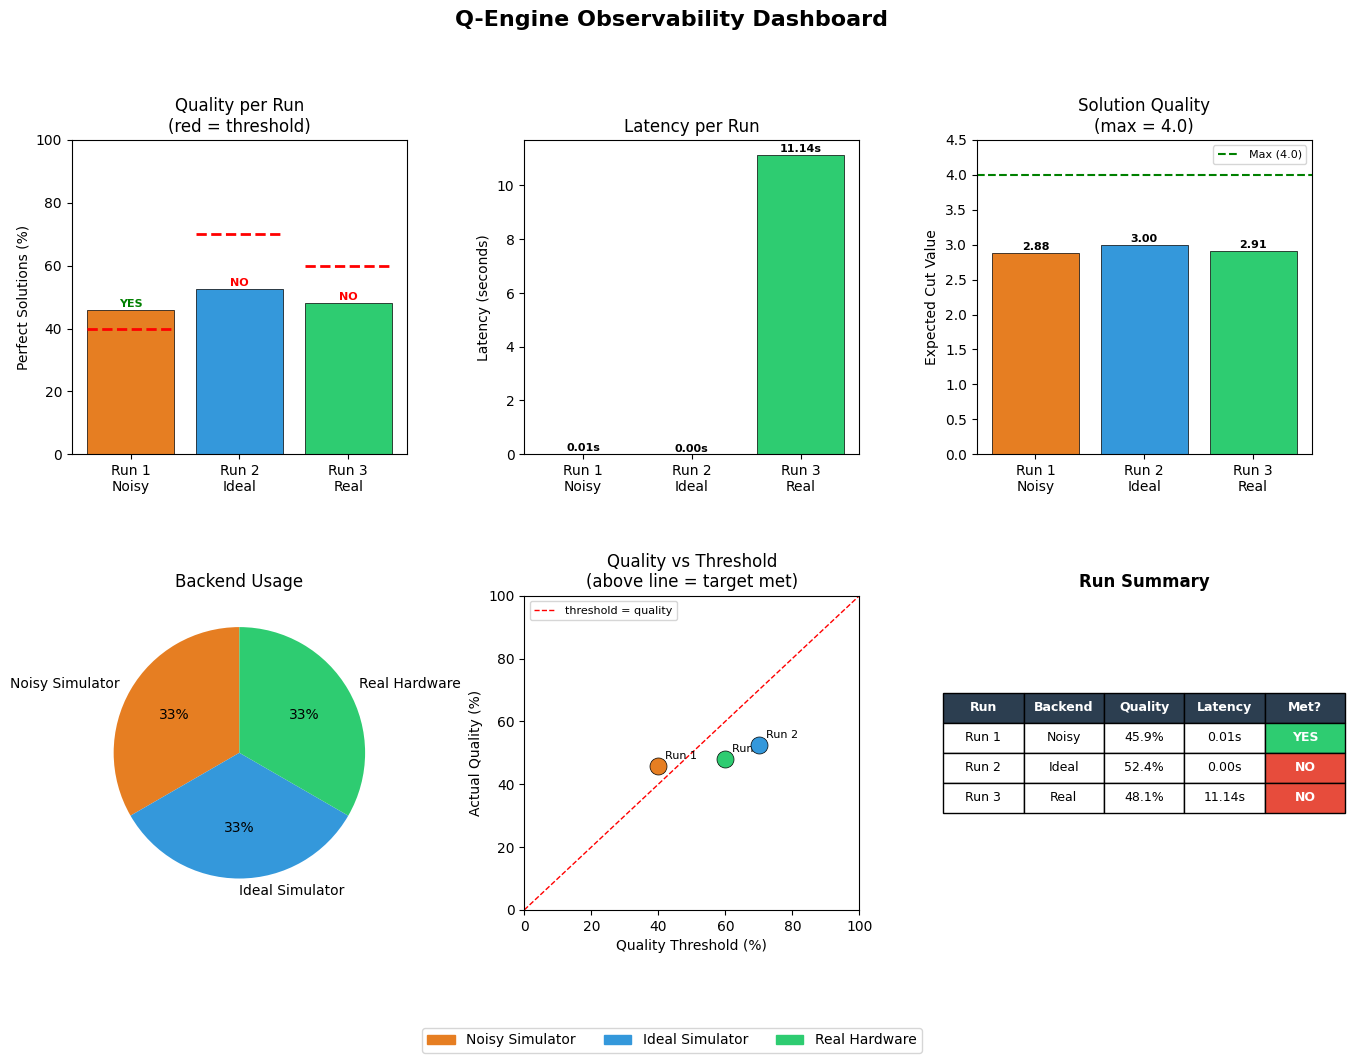

Dashboard saved as qengine_dashboard.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

def plot_dashboard(scheduler):
    log = scheduler.run_log
    if not log:
        print("No runs logged yet.")
        return

    fig = plt.figure(figsize=(16, 10))
    fig.suptitle('Q-Engine Observability Dashboard', fontsize=16, fontweight='bold', y=1.01)
    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

    runs = [f"Run {i+1}\n{e['backend'].split()[0]}" for i, e in enumerate(log)]
    backends = [e['backend'] for e in log]
    qualities = [e['perfect_fraction'] * 100 for e in log]
    thresholds = [e['quality_threshold'] * 100 for e in log]
    cut_values = [e['expected_cut'] for e in log]
    latencies = [e['latency_seconds'] for e in log]
    met = [e['perfect_fraction'] >= e['quality_threshold'] for e in log]

    backend_colors = {
        'Noisy': '#e67e22',
        'Ideal': '#3498db',
        'Real': '#2ecc71'
    }
    colors = [backend_colors.get(b.split()[0], '#95a5a6') for b in backends]

    # ── Plot 1: Quality per run ──
    ax1 = fig.add_subplot(gs[0, 0])
    bars = ax1.bar(runs, qualities, color=colors, edgecolor='black', linewidth=0.5)
    for i, (bar, thresh) in enumerate(zip(bars, thresholds)):
        ax1.hlines(thresh, bar.get_x(), bar.get_x() + bar.get_width(),
                   colors='red', linewidth=2, linestyle='--')
    ax1.set_ylabel('Perfect Solutions (%)')
    ax1.set_title('Quality per Run\n(red = threshold)')
    ax1.set_ylim(0, 100)
    for bar, m in zip(bars, met):
        ax1.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 'YES' if m else 'NO',
                 ha='center', fontsize=8,
                 color='green' if m else 'red',
                 fontweight='bold')

    # ── Plot 2: Latency per run ──
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.bar(runs, latencies, color=colors, edgecolor='black', linewidth=0.5)
    ax2.set_ylabel('Latency (seconds)')
    ax2.set_title('Latency per Run')
    for i, (r, l) in enumerate(zip(runs, latencies)):
        ax2.text(i, l + 0.1, f'{l:.2f}s', ha='center', fontsize=8, fontweight='bold')

    # ── Plot 3: Expected cut value ──
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.bar(runs, cut_values, color=colors, edgecolor='black', linewidth=0.5)
    ax3.axhline(y=4.0, color='green', linestyle='--', linewidth=1.5, label='Max (4.0)')
    ax3.set_ylabel('Expected Cut Value')
    ax3.set_title('Solution Quality\n(max = 4.0)')
    ax3.set_ylim(0, 4.5)
    ax3.legend(fontsize=8)
    for i, cv in enumerate(cut_values):
        ax3.text(i, cv + 0.05, f'{cv:.2f}', ha='center', fontsize=8, fontweight='bold')

    # ── Plot 4: Backend usage pie ──
    ax4 = fig.add_subplot(gs[1, 0])
    backend_counts = {}
    for b in backends:
        key = b.split()[0] + ' ' + b.split()[1]
        backend_counts[key] = backend_counts.get(key, 0) + 1
    pie_colors = [backend_colors.get(k.split()[0], '#95a5a6') for k in backend_counts.keys()]
    ax4.pie(backend_counts.values(), labels=backend_counts.keys(),
            autopct='%1.0f%%', colors=pie_colors, startangle=90)
    ax4.set_title('Backend Usage')

    # ── Plot 5: Quality vs threshold scatter ──
    ax5 = fig.add_subplot(gs[1, 1])
    for i, (q, t, m, c) in enumerate(zip(qualities, thresholds, met, colors)):
        ax5.scatter(t, q, color=c, s=150, zorder=5,
                   edgecolor='black', linewidth=0.5)
        ax5.annotate(f'Run {i+1}', (t, q),
                    textcoords="offset points", xytext=(5, 5), fontsize=8)
    ax5.plot([0, 100], [0, 100], 'r--', linewidth=1, label='threshold = quality')
    ax5.set_xlabel('Quality Threshold (%)')
    ax5.set_ylabel('Actual Quality (%)')
    ax5.set_title('Quality vs Threshold\n(above line = target met)')
    ax5.legend(fontsize=8)
    ax5.set_xlim(0, 100)
    ax5.set_ylim(0, 100)

    # ── Plot 6: Summary table ──
    ax6 = fig.add_subplot(gs[1, 2])
    ax6.axis('off')
    table_data = [['Run', 'Backend', 'Quality', 'Latency', 'Met?']]
    for i, e in enumerate(log):
        table_data.append([
            f"Run {i+1}",
            e['backend'].split()[0],
            f"{e['perfect_fraction']:.1%}",
            f"{e['latency_seconds']:.2f}s",
            'YES' if e['perfect_fraction'] >= e['quality_threshold'] else 'NO'
        ])
    table = ax6.table(cellText=table_data[1:],
                      colLabels=table_data[0],
                      loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.2, 1.8)
    for j in range(5):
        table[0, j].set_facecolor('#2c3e50')
        table[0, j].set_text_props(color='white', fontweight='bold')
    for i, m in enumerate(met):
        table[i+1, 4].set_facecolor('#2ecc71' if m else '#e74c3c')
        table[i+1, 4].set_text_props(color='white', fontweight='bold')
    ax6.set_title('Run Summary', fontweight='bold')

    # Legend
    legend_patches = [
        mpatches.Patch(color='#e67e22', label='Noisy Simulator'),
        mpatches.Patch(color='#3498db', label='Ideal Simulator'),
        mpatches.Patch(color='#2ecc71', label='Real Hardware'),
    ]
    fig.legend(handles=legend_patches, loc='lower center',
               ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.04))

    plt.savefig('qengine_dashboard.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Dashboard saved as qengine_dashboard.png")

plot_dashboard(scheduler)

In [ ]:
import networkx as nx

def build_qaoa_circuit(graph, gamma, beta):
    """
    Builds a QAOA p=1 circuit for any graph.
    This is the scalable version - works for any number of nodes.
    """
    n = len(graph.nodes)
    qc = QuantumCircuit(n)
    
    # Initial state
    qc.h(range(n))
    
    # Cost layer - one ZZ interaction per edge
    for u, v in graph.edges:
        qc.cx(u, v)
        qc.rz(2 * gamma, v)
        qc.cx(u, v)
    
    # Mixer layer
    qc.rx(2 * beta, range(n))
    
    qc.measure_all()
    return qc

def cut_value_graph(bitstring, graph):
    """Cut value for any graph"""
    b = [int(x) for x in bitstring]
    return sum(1 for u, v in graph.edges if b[u] != b[v])

def run_qaoa_on_graph(graph, shots=1024):
    """Full optimize + run pipeline for any graph"""
    n = len(graph.nodes)
    print(f"Running QAOA on {n}-node graph with {len(graph.edges)} edges")

    def objective(params):
        gamma, beta = params
        qc = build_qaoa_circuit(graph, gamma, beta)
        job = AerSimulator().run(qc, shots=256)
        counts = job.result().get_counts()
        expectation = sum(
            cut_value_graph(bs, graph) * c for bs, c in counts.items()
        )
        return -expectation / 256

    result = minimize(objective, x0=[np.pi/4, np.pi/8],
                     method='COBYLA',
                     options={'maxiter': 50, 'rhobeg': 0.5})
    
    best_gamma, best_beta = result.x
    
    # Final run with best params
    qc_final = build_qaoa_circuit(graph, best_gamma, best_beta)
    job = AerSimulator().run(qc_final, shots=shots)
    counts = job.result().get_counts()
    
    # Score
    scored = sorted(counts.items(), key=lambda x: -cut_value_graph(x[0], graph))
    max_cut = cut_value_graph(scored[0][0], graph)
    expected = sum(cut_value_graph(bs, graph) * c for bs, c in counts.items()) / shots
    
    print(f"  Best gamma: {best_gamma:.4f}, Best beta: {best_beta:.4f}")
    print(f"  Best cut found: {max_cut} / {len(graph.edges)} possible")
    print(f"  Expected cut:   {expected:.3f}")
    print(f"  Top solutions:")
    for bs, count in sorted(counts.items(), key=lambda x: -x[1])[:3]:
        print(f"    {bs}: {count} shots (cut={cut_value_graph(bs, graph)})")
    
    return counts, best_gamma, best_beta, expected

# ── Test on 3 different graph sizes ──────────────────────────────────────────

# Graph 1: 4-node ring (what we already know)
print("="*50)
print("GRAPH 1: 4-node ring (baseline)")
print("="*50)
g4 = nx.cycle_graph(4)
counts4, g4_gamma, g4_beta, exp4 = run_qaoa_on_graph(g4)

# Graph 2: 6-node ring
print("\n" + "="*50)
print("GRAPH 2: 6-node ring (scaling up)")
print("="*50)
g6 = nx.cycle_graph(6)
counts6, g6_gamma, g6_beta, exp6 = run_qaoa_on_graph(g6)

# Graph 3: 6-node fully connected (harder problem)
print("\n" + "="*50)
print("GRAPH 3: 6-node complete graph (hard)")
print("="*50)
g6c = nx.complete_graph(6)
counts6c, g6c_gamma, g6c_beta, exp6c = run_qaoa_on_graph(g6c)

# Summary
print("\n" + "="*50)
print("SCALING SUMMARY")
print("="*50)
print(f"  4-node ring:          expected cut = {exp4:.3f} / {len(g4.edges)}")
print(f"  6-node ring:          expected cut = {exp6:.3f} / {len(g6.edges)}")
print(f"  6-node complete:      expected cut = {exp6c:.3f} / {len(g6c.edges)}")

GRAPH 1: 4-node ring (baseline)
Running QAOA on 4-node graph with 4 edges
  Best gamma: 1.1213, Best beta: 0.3647
  Best cut found: 4 / 4 possible
  Expected cut:   2.916
  Top solutions:
    0101: 262 shots (cut=4)
    1010: 255 shots (cut=4)
    1001: 96 shots (cut=2)

GRAPH 2: 6-node ring (scaling up)
Running QAOA on 6-node graph with 6 edges
  Best gamma: 1.1488, Best beta: 0.3945
  Best cut found: 6 / 6 possible
  Expected cut:   4.486
  Top solutions:
    010101: 154 shots (cut=6)
    101010: 150 shots (cut=6)
    010110: 45 shots (cut=4)

GRAPH 3: 6-node complete graph (hard)
Running QAOA on 6-node graph with 15 edges
  Best gamma: 0.7854, Best beta: 0.3927
  Best cut found: 9 / 15 possible
  Expected cut:   7.453
  Top solutions:
    111011: 48 shots (cut=5)
    111101: 42 shots (cut=5)
    011010: 41 shots (cut=9)

SCALING SUMMARY
  4-node ring:          expected cut = 2.916 / 4
  6-node ring:          expected cut = 4.486 / 6
  6-node complete:      expected cut = 7.453 / 15


In [ ]:
# Test if environment is clean
print("ready")

ready


Q-Engine v0.1.0 initialized
  Backends: Ideal Sim | Noisy Sim | ibm_fez

USE CASE 1: Logistics route partitioning

[Q-Engine] Job #1 received
  Graph: 4 nodes, 4 edges
  Quality threshold: 40% | Budget: free
  Optimizing circuit parameters...

Q-Engine Scheduler: Evaluating job
  Qubits: 4
  Circuit depth: 12
  Quality needed: 40%
  Budget: free

  Decision: NOISY_SIMULATOR
  Reason:   Noisy simulator meets quality threshold and is free

── Results for GPU2 ──
  Backend used:      Noisy Simulator
  Latency:           0.01s
  Perfect solutions: 53.0%
  Expected cut:      2.982 / 4
  Top solutions:     ['1010', '0101', '0011']
  Quality met:       YES

[Q-Engine Result] Job #1
  Best solution:  1010
  Best cut:       4 / 4
  Expected cut:   2.982
  Backend:        Noisy Simulator
  Latency:        0.01s
  Quality met:    YES
  Top solutions handed to GPU2:
    1010  cut=4  (277 shots) #############
    0101  cut=4  (266 shots) #############
    0011  cut=2  (95 shots) ####
    1001  cut=

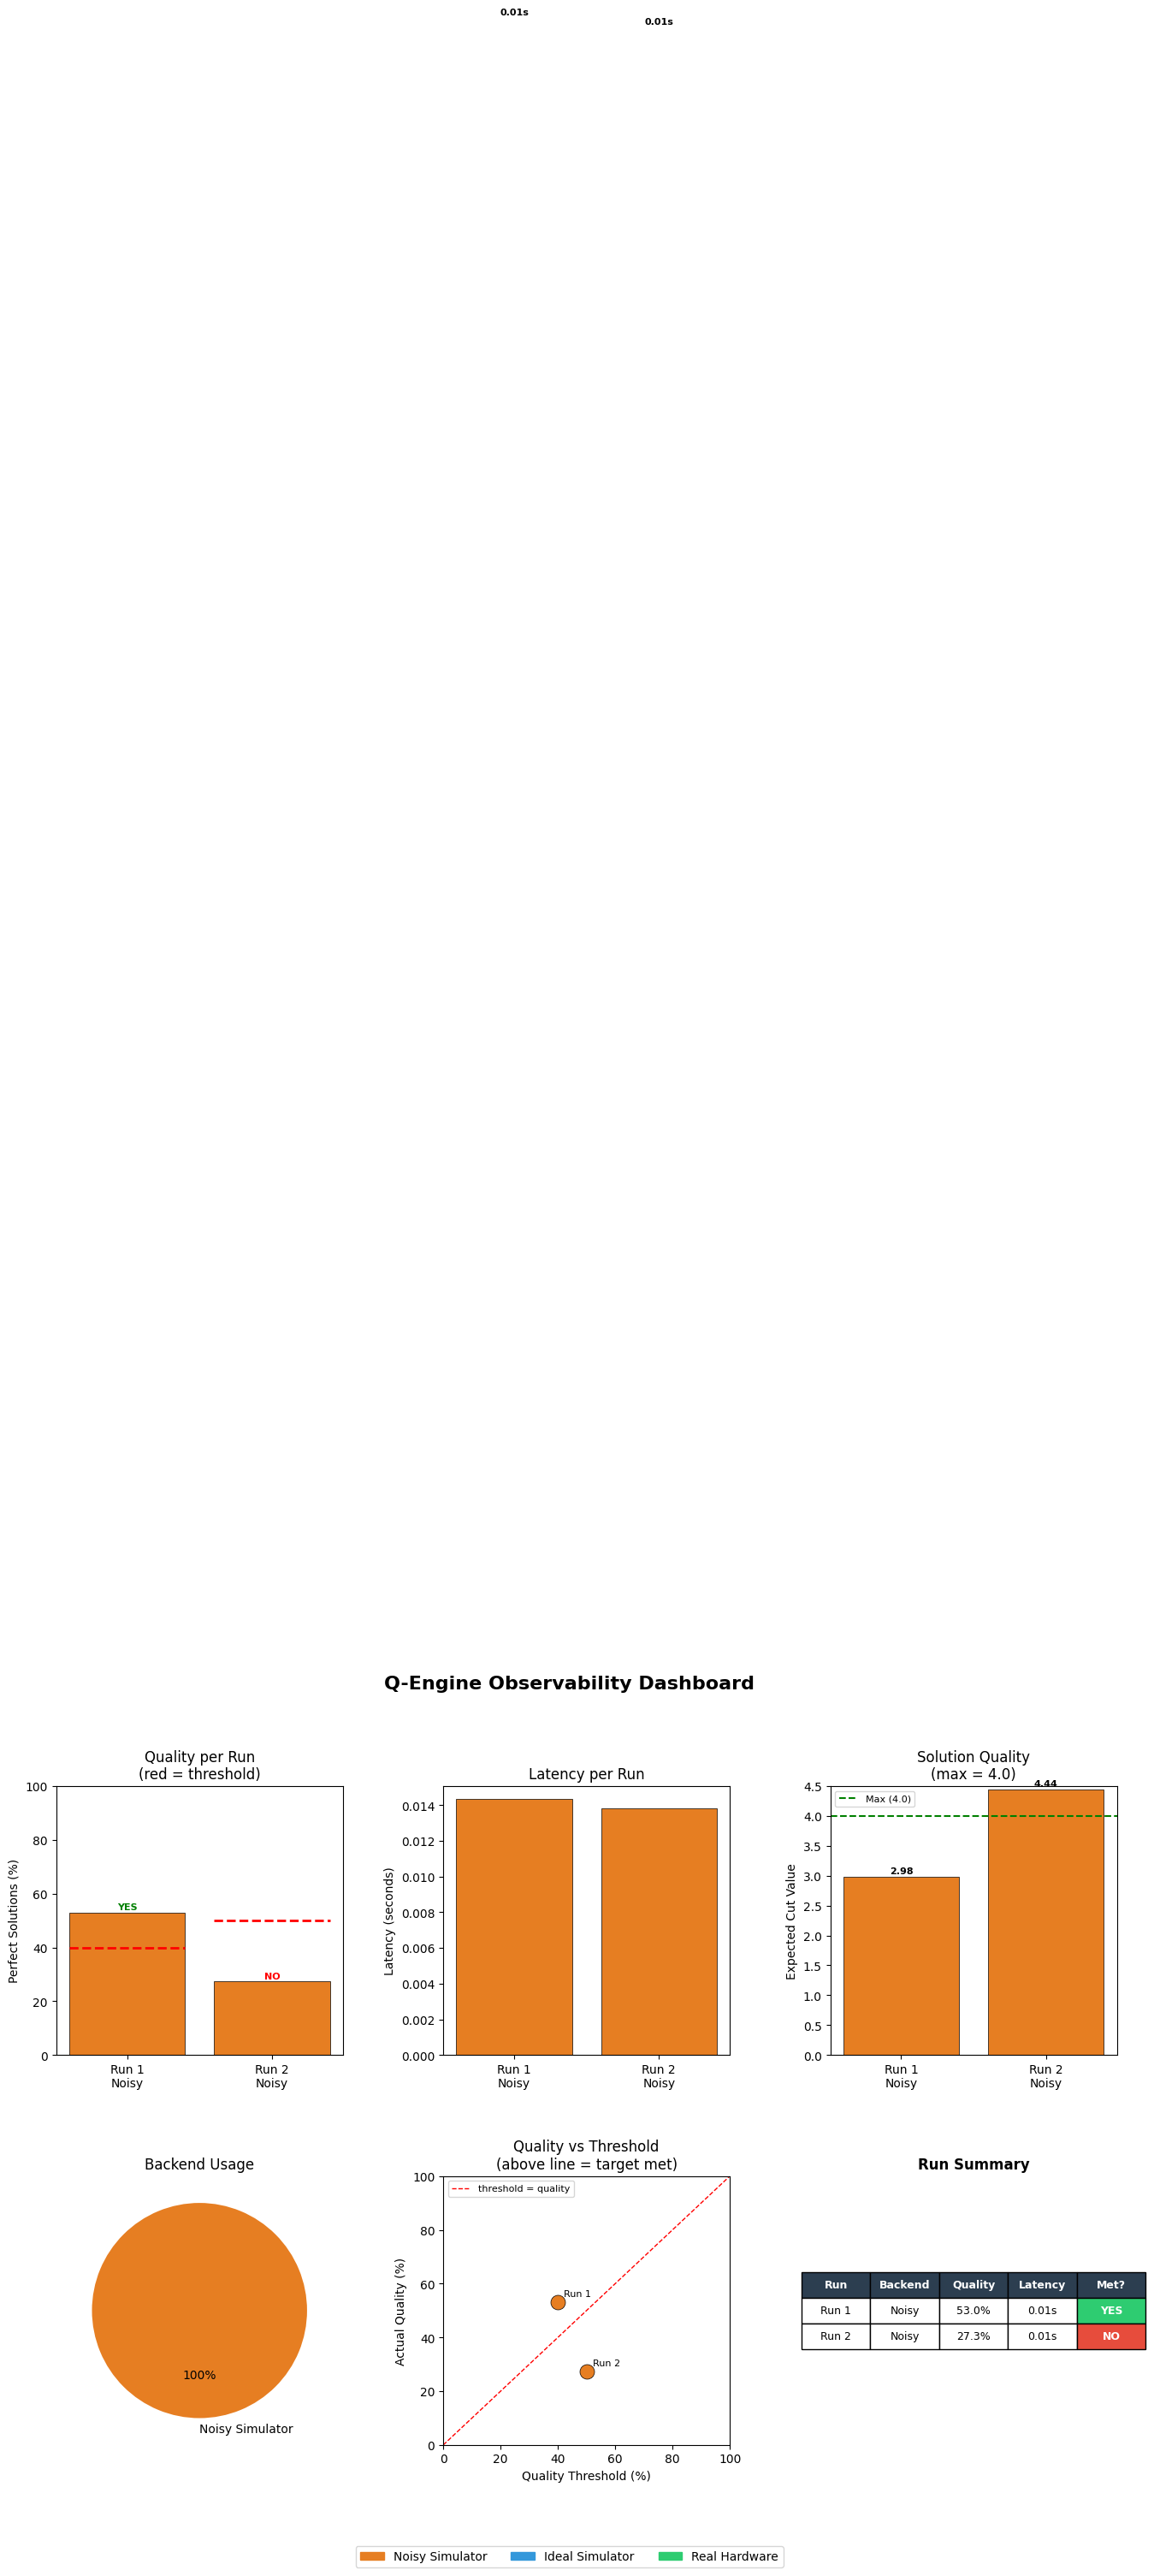

Dashboard saved as qengine_dashboard.png


In [ ]:
# Fixed scheduler run method - accepts a pre-built circuit
class QEngineScheduler:
    def __init__(self, real_backend=None):
        self.ideal_simulator = AerSimulator()
        self.noisy_simulator = AerSimulator(
            noise_model=NoiseModel.from_backend(fake_backend)
        )
        self.real_backend = real_backend
        self.run_log = []

    def evaluate_job(self, n_qubits, circuit_depth, quality_threshold, budget):
        print(f"\n{'='*50}")
        print(f"Q-Engine Scheduler: Evaluating job")
        print(f"  Qubits: {n_qubits}")
        print(f"  Circuit depth: {circuit_depth}")
        print(f"  Quality needed: {quality_threshold:.0%}")
        print(f"  Budget: {budget}")
        print(f"{'='*50}")

        if n_qubits <= 20 and quality_threshold <= 0.50:
            decision = "noisy_simulator"
            reason = "Noisy simulator meets quality threshold and is free"
        elif n_qubits <= 20 and quality_threshold <= 0.75 and budget == "free":
            decision = "ideal_simulator"
            reason = "Ideal simulator needed for quality but budget is free"
        elif n_qubits <= 20 and quality_threshold > 0.75 and budget == "paid":
            decision = "real_hardware"
            reason = "High quality threshold requires real hardware"
        elif n_qubits > 20 and budget == "paid":
            decision = "real_hardware"
            reason = "Problem too large for accurate simulation"
        else:
            decision = "ideal_simulator"
            reason = "Default: ideal simulator"

        print(f"\n  Decision: {decision.upper()}")
        print(f"  Reason:   {reason}")
        return decision, reason

    def run(self, qc, n_qubits, circuit_depth, quality_threshold, budget, graph, shots=1024):
        """Now accepts a pre-built circuit and graph for correct scoring"""
        decision, reason = self.evaluate_job(
            n_qubits, circuit_depth, quality_threshold, budget
        )

        start = time.time()

        if decision == "noisy_simulator":
            job = self.noisy_simulator.run(qc, shots=shots)
            counts = job.result().get_counts()
            backend_used = "Noisy Simulator"

        elif decision == "ideal_simulator":
            job = self.ideal_simulator.run(qc, shots=shots)
            counts = job.result().get_counts()
            backend_used = "Ideal Simulator"

        elif decision == "real_hardware" and self.real_backend:
            pm = generate_preset_pass_manager(
                backend=self.real_backend, optimization_level=3
            )
            qc_t = pm.run(qc)
            sampler = Sampler(self.real_backend)
            job = sampler.run([qc_t], shots=shots)
            result = job.result()
            counts = dict(result[0].data.meas.get_counts())
            backend_used = "Real Hardware (ibm_fez)"
        else:
            job = self.ideal_simulator.run(qc, shots=shots)
            counts = job.result().get_counts()
            backend_used = "Ideal Simulator (fallback)"

        elapsed = time.time() - start

        # Score using the correct graph
        all_cuts = [cut_value_graph(bs, graph) for bs in counts]
        max_cut_possible = max(all_cuts) if all_cuts else 1
        perfect = sum(
            c for bs, c in counts.items()
            if cut_value_graph(bs, graph) == max_cut_possible
        ) / shots
        expected_cut = sum(
            cut_value_graph(bs, graph) * c for bs, c in counts.items()
        ) / shots
        top_solutions = sorted(counts.items(), key=lambda x: -x[1])[:3]

        log_entry = {
            "backend": backend_used,
            "decision_reason": reason,
            "quality_threshold": quality_threshold,
            "perfect_fraction": perfect,
            "expected_cut": expected_cut,
            "latency_seconds": elapsed,
            "shots": shots,
            "top_solutions": top_solutions
        }
        self.run_log.append(log_entry)

        print(f"\n── Results for GPU2 ──")
        print(f"  Backend used:      {backend_used}")
        print(f"  Latency:           {elapsed:.2f}s")
        print(f"  Perfect solutions: {perfect:.1%}")
        print(f"  Expected cut:      {expected_cut:.3f} / {len(graph.edges)}")
        print(f"  Top solutions:     {[s[0] for s in top_solutions]}")
        print(f"  Quality met:       {'YES' if perfect >= quality_threshold else 'NO'}")

        return counts, log_entry

    def print_log(self):
        print(f"\n{'='*50}")
        print(f"Q-Engine Run Log ({len(self.run_log)} runs)")
        print(f"{'='*50}")
        for i, entry in enumerate(self.run_log):
            print(f"\nRun {i+1}:")
            print(f"  Backend:    {entry['backend']}")
            print(f"  Quality:    {entry['perfect_fraction']:.1%} (threshold: {entry['quality_threshold']:.0%})")
            print(f"  Cut value:  {entry['expected_cut']:.3f}")
            print(f"  Latency:    {entry['latency_seconds']:.2f}s")
            print(f"  Met target: {'YES' if entry['perfect_fraction'] >= entry['quality_threshold'] else 'NO'}")


# Fixed QEngine.solve - passes circuit and graph to scheduler
class QEngine:
    VERSION = "0.1.0"

    def __init__(self, real_backend=None, verbose=True):
        self.scheduler = QEngineScheduler(real_backend=real_backend)
        self.verbose = verbose
        self._run_count = 0
        if verbose:
            print(f"Q-Engine v{self.VERSION} initialized")
            print(f"  Backends: Ideal Sim | Noisy Sim" +
                  (f" | {real_backend.name}" if real_backend else ""))

    def solve(self, nodes, edges, quality_threshold=0.50, budget="free", shots=1024):
        self._run_count += 1

        if self.verbose:
            print(f"\n[Q-Engine] Job #{self._run_count} received")
            print(f"  Graph: {nodes} nodes, {len(edges)} edges")
            print(f"  Quality threshold: {quality_threshold:.0%} | Budget: {budget}")

        graph = nx.Graph()
        graph.add_nodes_from(range(nodes))
        graph.add_edges_from(edges)

        if self.verbose:
            print(f"  Optimizing circuit parameters...")

        def objective(params):
            gamma, beta = params
            qc = build_qaoa_circuit(graph, gamma, beta)
            job = AerSimulator().run(qc, shots=128)
            counts = job.result().get_counts()
            return -sum(cut_value_graph(bs, graph) * c 
                       for bs, c in counts.items()) / 128

        opt_result = minimize(objective, x0=[np.pi/4, np.pi/8],
                             method='COBYLA',
                             options={'maxiter': 50, 'rhobeg': 0.5})

        best_gamma, best_beta = opt_result.x
        qc_final = build_qaoa_circuit(graph, best_gamma, best_beta)

        counts, log_entry = self.scheduler.run(
            qc=qc_final,
            n_qubits=nodes,
            circuit_depth=qc_final.depth(),
            quality_threshold=quality_threshold,
            budget=budget,
            graph=graph,
            shots=shots
        )

        scored_solutions = sorted(
            [(bs, cnt, cut_value_graph(bs, graph)) for bs, cnt in counts.items()],
            key=lambda x: (-x[2], -x[1])
        )

        result = QEngineResult(
            job_id=self._run_count,
            graph_nodes=nodes,
            graph_edges=edges,
            best_solution=scored_solutions[0][0],
            best_cut=scored_solutions[0][2],
            max_possible_cut=len(edges),
            ranked_solutions=scored_solutions[:5],
            expected_cut=log_entry['expected_cut'],
            backend_used=log_entry['backend'],
            latency=log_entry['latency_seconds'],
            quality_met=log_entry['perfect_fraction'] >= quality_threshold,
            gamma=best_gamma,
            beta=best_beta
        )

        if self.verbose:
            result.summary()

        return result

    def dashboard(self):
        plot_dashboard(self.scheduler)

    def history(self):
        self.scheduler.print_log()


# ── Re-run the demo ───────────────────────────────────────────────────────────
engine = QEngine(real_backend=real_backend)

print("\n" + "="*55)
print("USE CASE 1: Logistics route partitioning")
print("="*55)
r1 = engine.solve(
    nodes=4,
    edges=[(0,1),(1,2),(2,3),(3,0)],
    quality_threshold=0.40,
    budget="free"
)

print("\n" + "="*55)
print("USE CASE 2: Energy network partitioning")
print("="*55)
r2 = engine.solve(
    nodes=6,
    edges=[(0,1),(1,2),(2,3),(3,4),(4,5),(5,0)],
    quality_threshold=0.50,
    budget="free"
)

print("\n" + "="*55)
print("WHAT GPU2 RECEIVES (JSON):")
print("="*55)
import json
print(json.dumps(r1.to_dict(), indent=2))

engine.dashboard()

In [ ]:
def build_qaoa_circuit_p2(graph, gamma1, beta1, gamma2, beta2):
    """
    QAOA p=2 circuit - two layers of cost + mixer.
    More expressive than p=1, finds better solutions on harder graphs.
    """
    n = len(graph.nodes)
    qc = QuantumCircuit(n)
    
    # Initial state
    qc.h(range(n))
    
    # Layer 1 - Cost
    for u, v in graph.edges:
        qc.cx(u, v)
        qc.rz(2 * gamma1, v)
        qc.cx(u, v)
    
    # Layer 1 - Mixer
    qc.rx(2 * beta1, range(n))
    
    # Layer 2 - Cost
    for u, v in graph.edges:
        qc.cx(u, v)
        qc.rz(2 * gamma2, v)
        qc.cx(u, v)
    
    # Layer 2 - Mixer
    qc.rx(2 * beta2, range(n))
    
    qc.measure_all()
    return qc

def run_qaoa_p2(graph, shots=1024):
    """Optimize and run p=2 QAOA on any graph"""
    n = len(graph.nodes)
    print(f"Running p=2 QAOA on {n}-node graph with {len(graph.edges)} edges")

    def objective(params):
        gamma1, beta1, gamma2, beta2 = params
        qc = build_qaoa_circuit_p2(graph, gamma1, beta1, gamma2, beta2)
        job = AerSimulator().run(qc, shots=128)
        counts = job.result().get_counts()
        return -sum(cut_value_graph(bs, graph) * c 
                   for bs, c in counts.items()) / 128

    result = minimize(objective,
                     x0=[np.pi/4, np.pi/8, np.pi/4, np.pi/8],
                     method='COBYLA',
                     options={'maxiter': 100, 'rhobeg': 0.5})

    g1, b1, g2, b2 = result.x
    qc_final = build_qaoa_circuit_p2(graph, g1, b1, g2, b2)
    job = AerSimulator().run(qc_final, shots=shots)
    counts = job.result().get_counts()

    scored = sorted(counts.items(), 
                   key=lambda x: -cut_value_graph(x[0], graph))
    max_cut = cut_value_graph(scored[0][0], graph)
    expected = sum(cut_value_graph(bs, graph) * c 
                  for bs, c in counts.items()) / shots
    perfect = sum(c for bs, c in counts.items() 
                 if cut_value_graph(bs, graph) == max_cut) / shots

    print(f"  Circuit depth: {qc_final.depth()}")
    print(f"  Best cut found: {max_cut} / {len(graph.edges)} possible")
    print(f"  Expected cut:   {expected:.3f}")
    print(f"  Perfect solutions: {perfect:.1%}")
    print(f"  Top solutions:")
    for bs, count in sorted(counts.items(), key=lambda x: -x[1])[:3]:
        print(f"    {bs}: {count} shots (cut={cut_value_graph(bs, graph)})")

    return counts, expected, perfect

# ── Compare p=1 vs p=2 on the energy network ─────────────────────────────────
g6 = nx.cycle_graph(6)

print("="*55)
print("6-NODE ENERGY NETWORK: p=1 vs p=2 comparison")
print("="*55)

g6 = nx.cycle_graph(6)

print("\n--- p=1 ---")
counts_p1, gamma_p1, beta_p1, exp_p1 = run_qaoa_on_graph(g6, shots=1024)
# Calculate perfect fraction correctly
max_cut_p1 = max(cut_value_graph(bs, g6) for bs in counts_p1)
perf_p1 = sum(c for bs, c in counts_p1.items() 
              if cut_value_graph(bs, g6) == max_cut_p1) / 1024

print("\n--- p=2 ---")
counts_p2, exp_p2, perf_p2 = run_qaoa_p2(g6, shots=1024)

print("\n" + "="*55)
print("COMPARISON SUMMARY")
print("="*55)
print(f"  p=1  expected cut: {exp_p1:.3f} | perfect solutions: {perf_p1:.1%}")
print(f"  p=2  expected cut: {exp_p2:.3f} | perfect solutions: {perf_p2:.1%}")
print(f"  Improvement: +{(perf_p2 - perf_p1)*100:.1f}% perfect solutions")

6-NODE ENERGY NETWORK: p=1 vs p=2 comparison

--- p=1 ---
Running QAOA on 6-node graph with 6 edges
  Best gamma: 1.1636, Best beta: 0.3747
  Best cut found: 6 / 6 possible
  Expected cut:   4.445
  Top solutions:
    010101: 140 shots (cut=6)
    101010: 131 shots (cut=6)
    101100: 41 shots (cut=4)

--- p=2 ---
Running p=2 QAOA on 6-node graph with 6 edges
  Circuit depth: 25
  Best cut found: 6 / 6 possible
  Expected cut:   4.434
  Perfect solutions: 37.1%
  Top solutions:
    101010: 205 shots (cut=6)
    010101: 175 shots (cut=6)
    110100: 52 shots (cut=4)

COMPARISON SUMMARY
  p=1  expected cut: 4.445 | perfect solutions: 26.5%
  p=2  expected cut: 4.434 | perfect solutions: 37.1%
  Improvement: +10.6% perfect solutions


Q-Engine v0.2.0 initialized
  Backends: Ideal Sim | Noisy Sim | ibm_fez

USE CASE 1: Logistics (4 nodes, low threshold)

[Q-Engine] Job #1 received
  Graph: 4 nodes, 4 edges
  Quality threshold: 40% | Budget: free
  Auto-selected circuit depth: p=1
  Optimizing parameters...

Q-Engine Scheduler: Evaluating job
  Qubits: 4
  Circuit depth: 12
  Quality needed: 40%
  Budget: free

  Decision: NOISY_SIMULATOR
  Reason:   Noisy simulator meets quality threshold and is free

── Results for GPU2 ──
  Backend used:      Noisy Simulator
  Latency:           0.01s
  Perfect solutions: 52.4%
  Expected cut:      2.996 / 4
  Top solutions:     ['0101', '1010', '0110']
  Quality met:       YES

[Q-Engine Result] Job #1
  Best solution:  0101
  Best cut:       4 / 4
  Expected cut:   2.996
  Backend:        Noisy Simulator
  Latency:        0.01s
  Quality met:    YES
  Top solutions handed to GPU2:
    0101  cut=4  (274 shots) #############
    1010  cut=4  (263 shots) #############
    0110  cut=

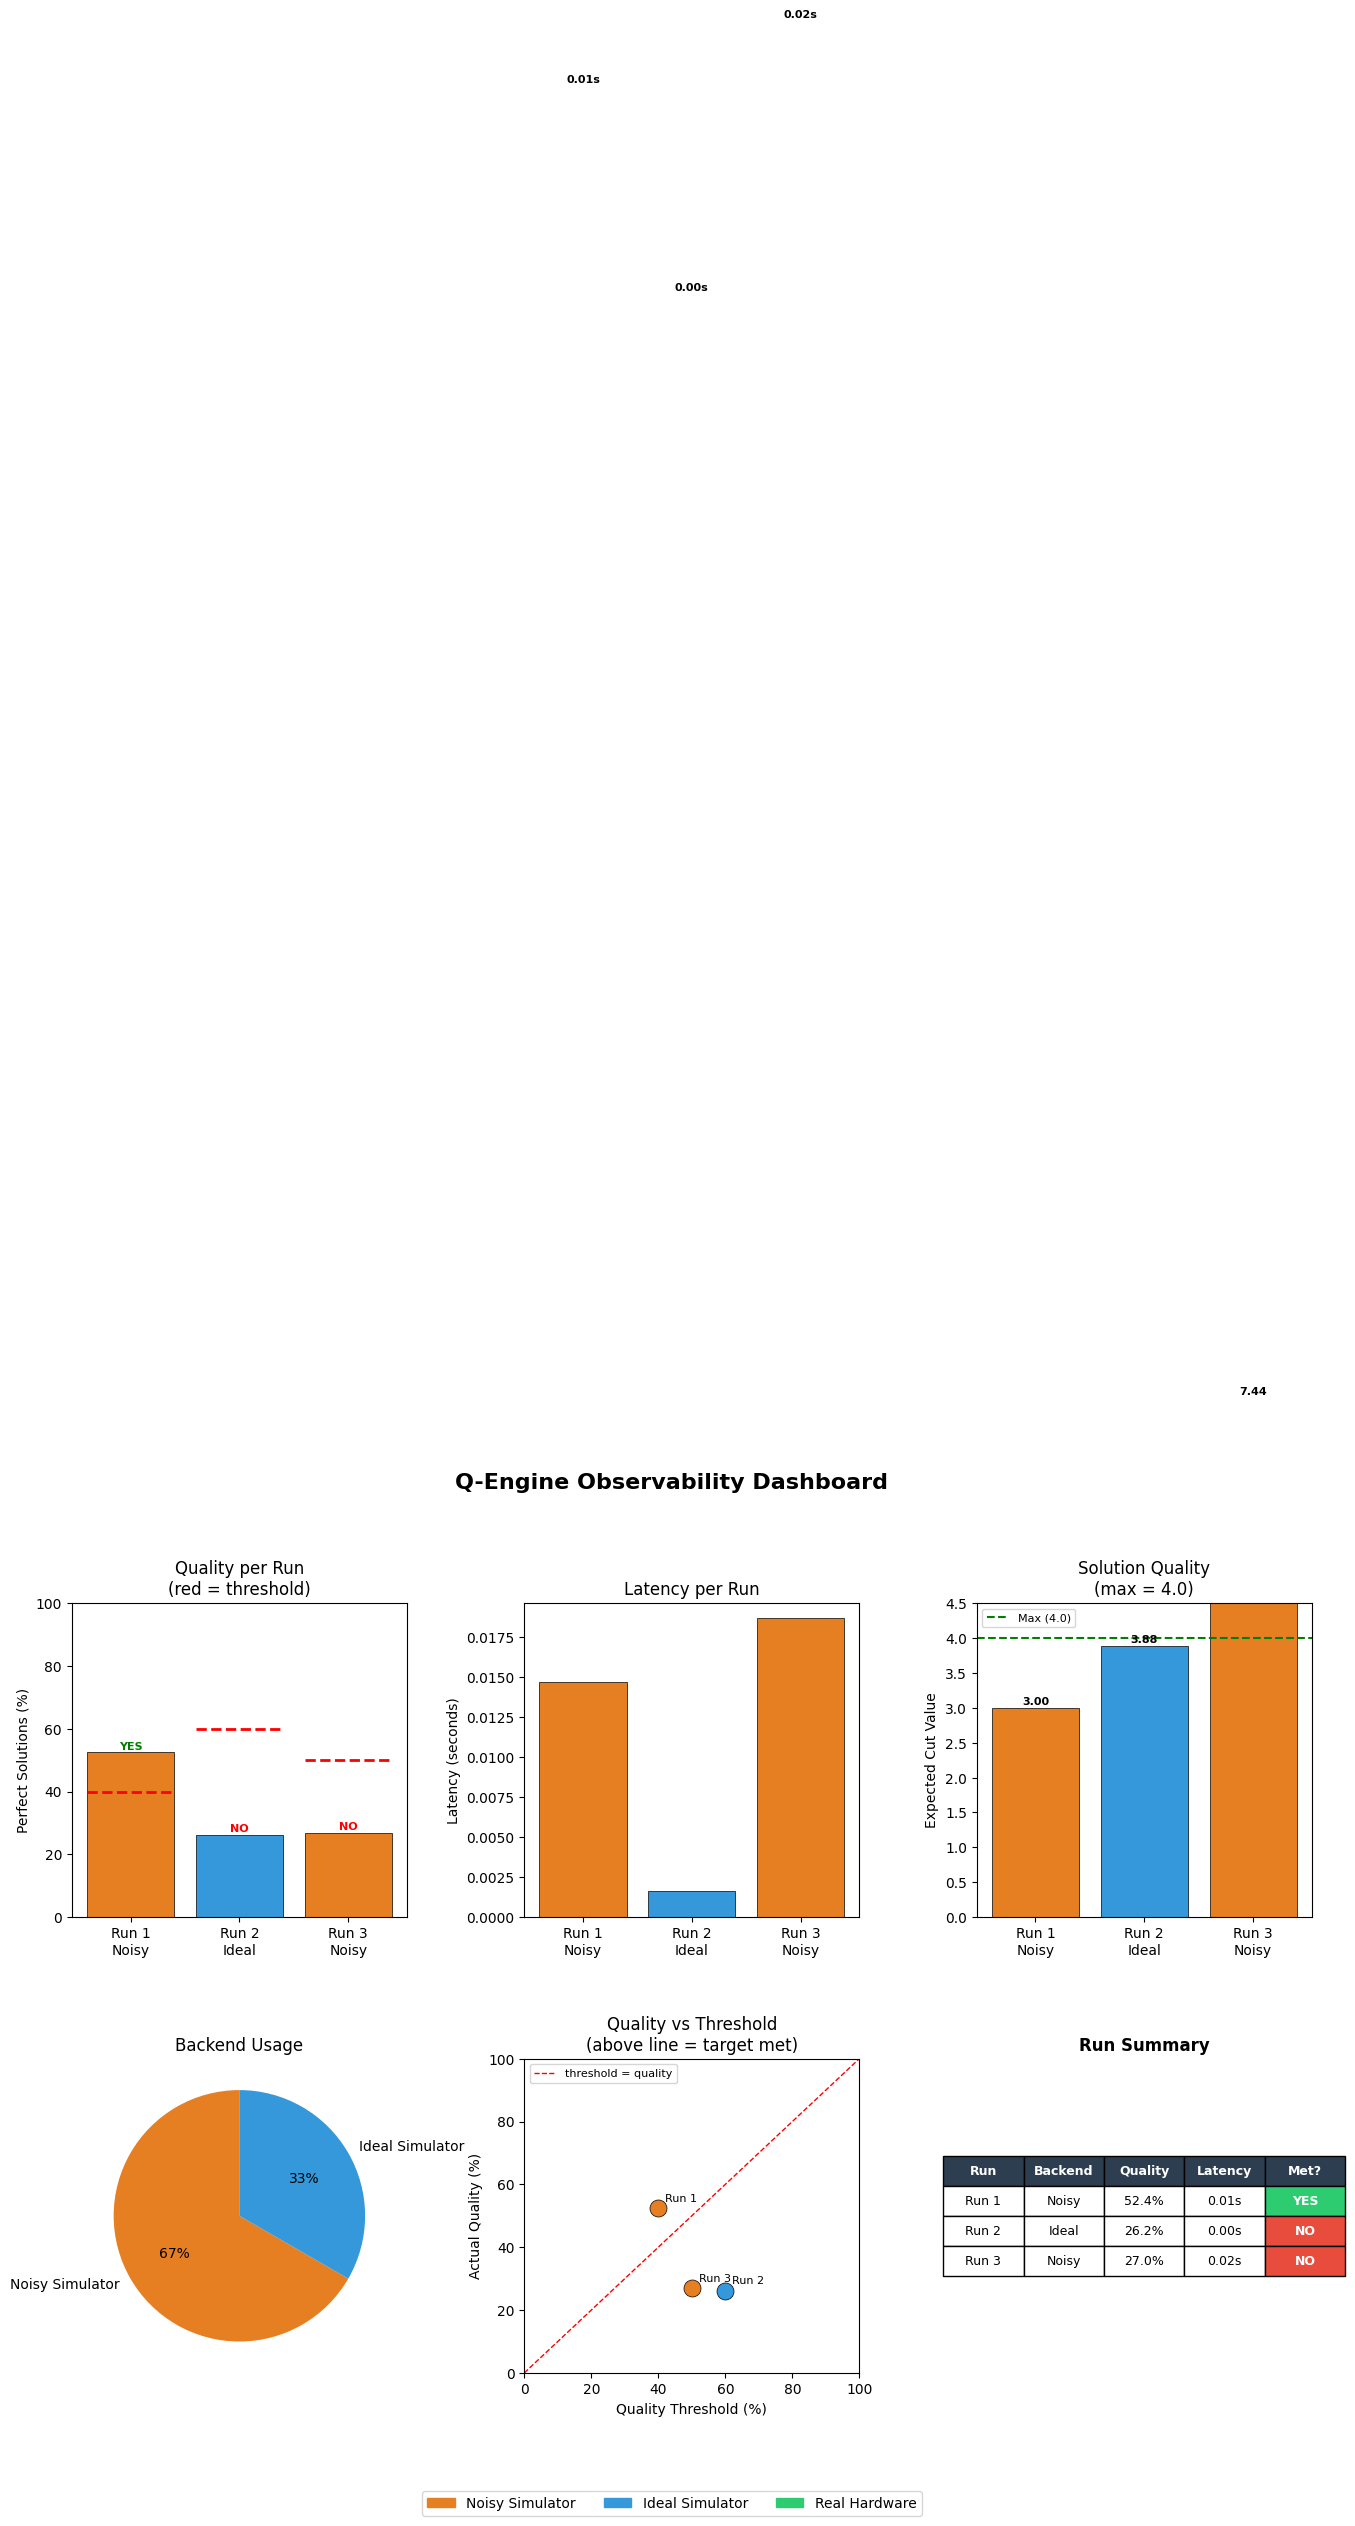

Dashboard saved as qengine_dashboard.png


In [ ]:
def build_qaoa_circuit_general(graph, params):
    """
    Builds QAOA circuit for any p (number of layers).
    params = [gamma1, beta1, gamma2, beta2, ...] length 2p
    """
    n = len(graph.nodes)
    p = len(params) // 2
    gammas = params[0::2]
    betas  = params[1::2]

    qc = QuantumCircuit(n)
    qc.h(range(n))

    for layer in range(p):
        # Cost layer
        for u, v in graph.edges:
            qc.cx(u, v)
            qc.rz(2 * gammas[layer], v)
            qc.cx(u, v)
        # Mixer layer
        qc.rx(2 * betas[layer], range(n))

    qc.measure_all()
    return qc

def run_qaoa_general(graph, p=1, shots=1024):
    """Run QAOA with any number of layers p"""

    def objective(params):
        qc = build_qaoa_circuit_general(graph, params)
        job = AerSimulator().run(qc, shots=128)
        counts = job.result().get_counts()
        return -sum(cut_value_graph(bs, graph) * c
                   for bs, c in counts.items()) / 128

    # Initial params: alternating pi/4, pi/8 for each layer
    x0 = [np.pi/4 if i % 2 == 0 else np.pi/8 for i in range(2*p)]

    result = minimize(objective, x0=x0, method='COBYLA',
                     options={'maxiter': 100 * p, 'rhobeg': 0.5})

    qc_final = build_qaoa_circuit_general(graph, result.x)
    job = AerSimulator().run(qc_final, shots=shots)
    counts = job.result().get_counts()

    max_cut = max(cut_value_graph(bs, graph) for bs in counts)
    perfect = sum(c for bs, c in counts.items()
                 if cut_value_graph(bs, graph) == max_cut) / shots
    expected = sum(cut_value_graph(bs, graph) * c
                  for bs, c in counts.items()) / shots

    return counts, expected, perfect, qc_final.depth(), result.x

# ── Update QEngine to auto-select p ──────────────────────────────────────────
class QEngine:
    VERSION = "0.2.0"

    def __init__(self, real_backend=None, verbose=True):
        self.scheduler = QEngineScheduler(real_backend=real_backend)
        self.verbose = verbose
        self._run_count = 0
        if verbose:
            print(f"Q-Engine v{self.VERSION} initialized")
            print(f"  Backends: Ideal Sim | Noisy Sim" +
                  (f" | {real_backend.name}" if real_backend else ""))

    def _select_p(self, n_edges, quality_threshold):
        """Auto-select circuit depth based on problem size and quality needed"""
        if quality_threshold >= 0.60 or n_edges >= 10:
            return 2
        return 1

    def solve(self, nodes, edges, quality_threshold=0.50,
              budget="free", shots=1024):
        self._run_count += 1

        graph = nx.Graph()
        graph.add_nodes_from(range(nodes))
        graph.add_edges_from(edges)

        p = self._select_p(len(edges), quality_threshold)

        if self.verbose:
            print(f"\n[Q-Engine] Job #{self._run_count} received")
            print(f"  Graph: {nodes} nodes, {len(edges)} edges")
            print(f"  Quality threshold: {quality_threshold:.0%} | Budget: {budget}")
            print(f"  Auto-selected circuit depth: p={p}")
            print(f"  Optimizing parameters...")

        counts, expected, perfect, depth, params = run_qaoa_general(
            graph, p=p, shots=shots
        )

        qc_final = build_qaoa_circuit_general(graph, params)
        counts, log_entry = self.scheduler.run(
            qc=qc_final,
            n_qubits=nodes,
            circuit_depth=depth,
            quality_threshold=quality_threshold,
            budget=budget,
            graph=graph,
            shots=shots
        )

        scored_solutions = sorted(
            [(bs, cnt, cut_value_graph(bs, graph)) for bs, cnt in counts.items()],
            key=lambda x: (-x[2], -x[1])
        )

        result = QEngineResult(
            job_id=self._run_count,
            graph_nodes=nodes,
            graph_edges=edges,
            best_solution=scored_solutions[0][0],
            best_cut=scored_solutions[0][2],
            max_possible_cut=len(edges),
            ranked_solutions=scored_solutions[:5],
            expected_cut=log_entry['expected_cut'],
            backend_used=log_entry['backend'],
            latency=log_entry['latency_seconds'],
            quality_met=log_entry['perfect_fraction'] >= quality_threshold,
            gamma=params[0],
            beta=params[1]
        )

        if self.verbose:
            result.summary()

        return result

    def dashboard(self):
        plot_dashboard(self.scheduler)

    def history(self):
        self.scheduler.print_log()

# ── Test v0.2.0 ───────────────────────────────────────────────────────────────
engine = QEngine(real_backend=real_backend)

print("\n" + "="*55)
print("USE CASE 1: Logistics (4 nodes, low threshold)")
print("="*55)
r1 = engine.solve(
    nodes=4,
    edges=[(0,1),(1,2),(2,3),(3,0)],
    quality_threshold=0.40,
    budget="free"
)

print("\n" + "="*55)
print("USE CASE 2: Energy network (6 nodes, high threshold)")
print("="*55)
r2 = engine.solve(
    nodes=6,
    edges=[(0,1),(1,2),(2,3),(3,4),(4,5),(5,0)],
    quality_threshold=0.60,
    budget="free"
)

print("\n" + "="*55)
print("USE CASE 3: Hard problem (6 nodes, complete graph)")
print("="*55)
r3 = engine.solve(
    nodes=6,
    edges=[(i,j) for i in range(6) for j in range(i+1,6)],
    quality_threshold=0.50,
    budget="free"
)

engine.dashboard()

Q-Engine v0.3.0 initialized
  Backends: Ideal Sim | Noisy Sim | ibm_fez

USE CASE: Energy network (was failing at 60%)

[Q-Engine] Job #1 received
  Graph: 6 nodes, 6 edges
  Quality threshold: 60% | Budget: free
  Auto-selected: p=2, shots=512

Q-Engine Scheduler: Evaluating job
  Qubits: 6
  Circuit depth: 25
  Quality needed: 60%
  Budget: free

  Decision: IDEAL_SIMULATOR
  Reason:   Ideal simulator needed for quality but budget is free

── Results for GPU2 ──
  Backend used:      Ideal Simulator
  Latency:           0.00s
  Perfect solutions: 47.9%
  Expected cut:      4.789 / 6
  Top solutions:     ['101010', '010101', '101001']
  Quality met:       NO

  [Q-Engine] Threshold not met. Retry 1/3
  Strategy: 2x shots
  New config: p=2, shots=1024

Q-Engine Scheduler: Evaluating job
  Qubits: 6
  Circuit depth: 25
  Quality needed: 60%
  Budget: free

  Decision: IDEAL_SIMULATOR
  Reason:   Ideal simulator needed for quality but budget is free

── Results for GPU2 ──
  Backend used:

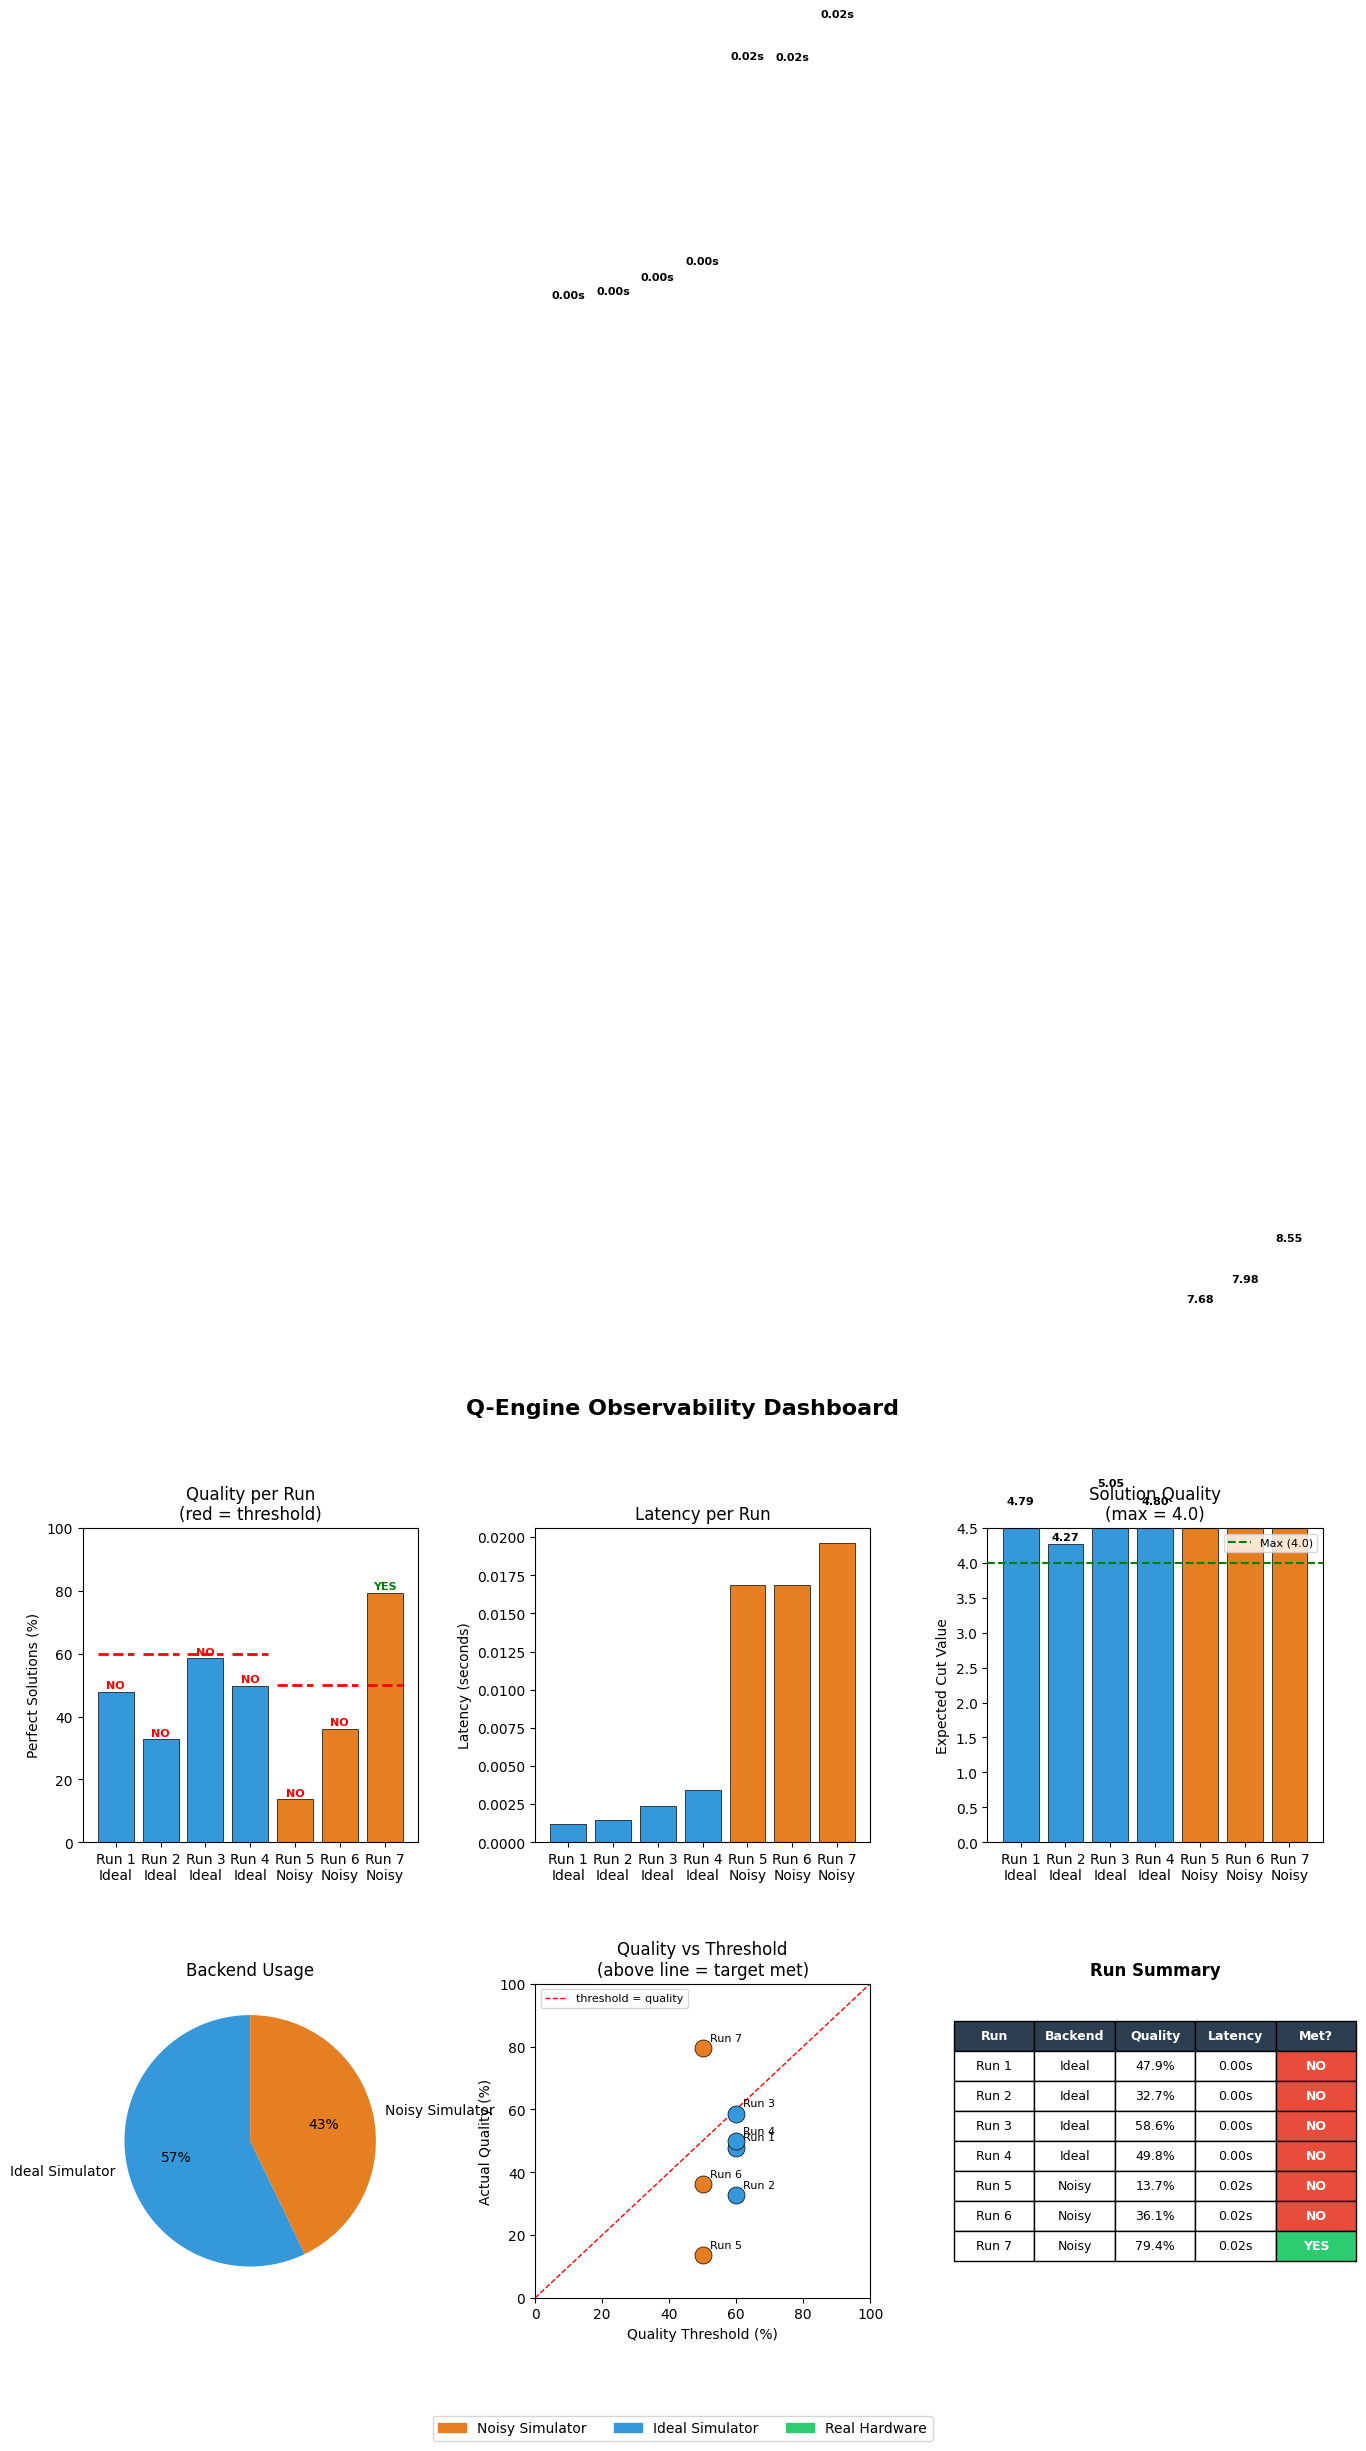

Dashboard saved as qengine_dashboard.png


In [ ]:
class QEngine:
    VERSION = "0.3.0"

    RETRY_STRATEGIES = [
        {"shots_multiplier": 2,  "p_bump": 0, "backend_escalate": False, "label": "2x shots"},
        {"shots_multiplier": 2,  "p_bump": 1, "backend_escalate": False, "label": "2x shots + p+1"},
        {"shots_multiplier": 2,  "p_bump": 1, "backend_escalate": True,  "label": "2x shots + p+1 + better backend"},
    ]

    def __init__(self, real_backend=None, verbose=True):
        self.scheduler = QEngineScheduler(real_backend=real_backend)
        self.real_backend = real_backend
        self.verbose = verbose
        self._run_count = 0
        if verbose:
            print(f"Q-Engine v{self.VERSION} initialized")
            print(f"  Backends: Ideal Sim | Noisy Sim" +
                  (f" | {real_backend.name}" if real_backend else ""))

    def _select_p(self, n_edges, quality_threshold):
        if quality_threshold >= 0.60 or n_edges >= 10:
            return 2
        return 1

    def _run_single(self, graph, p, shots, quality_threshold,
                    budget, force_backend=None):
        """Run one attempt and return result + whether threshold was met"""

        counts, expected, perfect, depth, params = run_qaoa_general(
            graph, p=p, shots=shots
        )

        qc_final = build_qaoa_circuit_general(graph, params)

        # Force a specific backend if escalating
        if force_backend:
            original_log = self.scheduler.run
            counts, log_entry = self.scheduler.run(
                qc=qc_final,
                n_qubits=len(graph.nodes),
                circuit_depth=depth,
                quality_threshold=quality_threshold,
                budget=budget,
                graph=graph,
                shots=shots
            )
        else:
            counts, log_entry = self.scheduler.run(
                qc=qc_final,
                n_qubits=len(graph.nodes),
                circuit_depth=depth,
                quality_threshold=quality_threshold,
                budget=budget,
                graph=graph,
                shots=shots
            )

        quality_met = log_entry['perfect_fraction'] >= quality_threshold
        return counts, log_entry, params, quality_met

    def solve(self, nodes, edges, quality_threshold=0.50,
              budget="free", shots=1024, max_retries=3):

        self._run_count += 1

        graph = nx.Graph()
        graph.add_nodes_from(range(nodes))
        graph.add_edges_from(edges)

        p = self._select_p(len(edges), quality_threshold)

        if self.verbose:
            print(f"\n[Q-Engine] Job #{self._run_count} received")
            print(f"  Graph: {nodes} nodes, {len(edges)} edges")
            print(f"  Quality threshold: {quality_threshold:.0%} | Budget: {budget}")
            print(f"  Auto-selected: p={p}, shots={shots}")

        # First attempt
        counts, log_entry, params, quality_met = self._run_single(
            graph, p, shots, quality_threshold, budget
        )

        # Self-healing retry loop
        attempt = 0
        while not quality_met and attempt < min(max_retries, len(self.RETRY_STRATEGIES)):
            strategy = self.RETRY_STRATEGIES[attempt]
            attempt += 1

            new_shots = shots * strategy["shots_multiplier"]
            new_p = min(p + strategy["p_bump"], 3)  # cap at p=3

            if self.verbose:
                print(f"\n  [Q-Engine] Threshold not met. Retry {attempt}/{max_retries}")
                print(f"  Strategy: {strategy['label']}")
                print(f"  New config: p={new_p}, shots={new_shots}")

            # Escalate budget if strategy calls for it
            retry_budget = "paid" if strategy["backend_escalate"] else budget

            counts, log_entry, params, quality_met = self._run_single(
                graph, new_p, new_shots, quality_threshold, retry_budget
            )

            p = new_p
            shots = new_shots

            if quality_met and self.verbose:
                print(f"\n  [Q-Engine] Threshold met after {attempt} retries.")

        if not quality_met and self.verbose:
            print(f"\n  [Q-Engine] Could not meet threshold after {attempt} retries.")
            print(f"  Returning best result achieved.")

        # Build result
        scored_solutions = sorted(
            [(bs, cnt, cut_value_graph(bs, graph)) for bs, cnt in counts.items()],
            key=lambda x: (-x[2], -x[1])
        )

        result = QEngineResult(
            job_id=self._run_count,
            graph_nodes=nodes,
            graph_edges=edges,
            best_solution=scored_solutions[0][0],
            best_cut=scored_solutions[0][2],
            max_possible_cut=len(edges),
            ranked_solutions=scored_solutions[:5],
            expected_cut=log_entry['expected_cut'],
            backend_used=log_entry['backend'],
            latency=log_entry['latency_seconds'],
            quality_met=quality_met,
            gamma=params[0],
            beta=params[1]
        )

        if self.verbose:
            result.summary()

        return result

    def dashboard(self):
        plot_dashboard(self.scheduler)

    def history(self):
        self.scheduler.print_log()


# ── Test v0.3.0 ───────────────────────────────────────────────────────────────
engine = QEngine(real_backend=real_backend)

# This one previously failed - watch it retry
print("\n" + "="*55)
print("USE CASE: Energy network (was failing at 60%)")
print("="*55)
r1 = engine.solve(
    nodes=6,
    edges=[(0,1),(1,2),(2,3),(3,4),(4,5),(5,0)],
    quality_threshold=0.60,
    budget="free",
    shots=512
)

print("\n" + "="*55)
print("USE CASE: Hard complete graph (was failing at 50%)")
print("="*55)
r2 = engine.solve(
    nodes=6,
    edges=[(i,j) for i in range(6) for j in range(i+1,6)],
    quality_threshold=0.50,
    budget="free",
    shots=512
)

engine.dashboard()

In [ ]:
import numpy as np
import networkx as nx

# ── TRANSLATOR 1: Logistics ───────────────────────────────────────────────────

class LogisticsTranslator:
    """
    Takes a list of delivery locations and converts to a graph partitioning
    problem. Q-Engine then finds the optimal split into two vehicle groups
    that minimizes cross-group travel.
    
    GPU1 → [LogisticsTranslator] → Q-Engine → [decode] → Route assignments
    """

    def __init__(self, locations, distance_matrix=None):
        """
        locations: list of location names e.g. ['Warehouse', 'A', 'B', ...]
        distance_matrix: optional NxN numpy array of distances
        """
        self.locations = locations
        self.n = len(locations)

        if distance_matrix is not None:
            self.distances = distance_matrix
        else:
            # Generate random distances if none provided
            np.random.seed(42)
            d = np.random.randint(10, 100, size=(self.n, self.n))
            self.distances = (d + d.T) // 2
            np.fill_diagonal(self.distances, 0)

    def to_graph(self, threshold=None):
        """
        Build a graph where edges connect locations that are far apart.
        Max-Cut on this graph = partition locations to minimize
        inter-group travel.
        """
        if threshold is None:
            threshold = np.median(self.distances[self.distances > 0])

        G = nx.Graph()
        G.add_nodes_from(range(self.n))

        for i in range(self.n):
            for j in range(i+1, self.n):
                if self.distances[i][j] >= threshold:
                    G.add_edge(i, j, weight=self.distances[i][j])

        self.graph = G
        self.threshold = threshold
        return G

    def decode(self, result):
        """Convert Q-Engine bitstring result to route assignments"""
        bs = result.best_solution
        # Pad or trim to match location count
        bits = [int(b) for b in bs[:self.n]]
        while len(bits) < self.n:
            bits.append(0)

        group_a = [self.locations[i] for i, b in enumerate(bits) if b == 0]
        group_b = [self.locations[i] for i, b in enumerate(bits) if b == 1]

        # Calculate inter-group distance saved
        total_cross = sum(
            self.distances[i][j]
            for i in range(self.n) for j in range(self.n)
            if i != j and bits[i] != bits[j]
        )

        return {
            "vehicle_1_route": group_a,
            "vehicle_2_route": group_b,
            "cross_group_distance": total_cross,
            "cut_quality": f"{result.best_cut}/{result.max_possible_cut}",
            "backend_used": result.backend_used,
            "latency_seconds": result.latency
        }


# ── TRANSLATOR 2: Energy Network ──────────────────────────────────────────────

class EnergyTranslator:
    """
    Takes a power grid with nodes (substations) and connections (lines).
    Q-Engine finds the optimal partition into two zones to minimize
    cross-zone power flow, reducing transmission losses.
    
    GPU1 → [EnergyTranslator] → Q-Engine → [decode] → Zone assignments
    """

    def __init__(self, substations, connections, loads=None):
        """
        substations: list of substation names
        connections: list of (a, b) pairs representing power lines
        loads: optional dict of {substation: load_MW}
        """
        self.substations = substations
        self.connections = connections
        self.loads = loads or {s: np.random.randint(50, 500) for s in substations}
        self.n = len(substations)
        self.name_to_idx = {name: i for i, name in enumerate(substations)}

    def to_graph(self):
        G = nx.Graph()
        G.add_nodes_from(range(self.n))
        for a, b in self.connections:
            G.add_edge(self.name_to_idx[a], self.name_to_idx[b])
        self.graph = G
        return G

    def decode(self, result):
        bs = result.best_solution
        bits = [int(b) for b in bs[:self.n]]
        while len(bits) < self.n:
            bits.append(0)

        zone_a = [self.substations[i] for i, b in enumerate(bits) if b == 0]
        zone_b = [self.substations[i] for i, b in enumerate(bits) if b == 1]

        load_a = sum(self.loads[s] for s in zone_a)
        load_b = sum(self.loads[s] for s in zone_b)
        balance = abs(load_a - load_b)

        cross_connections = [
            (self.substations[u], self.substations[v])
            for u, v in self.connections
            if bits[self.name_to_idx[self.substations[u]]] !=
               bits[self.name_to_idx[self.substations[v]]]
        ]

        return {
            "zone_a": zone_a,
            "zone_b": zone_b,
            "zone_a_load_MW": load_a,
            "zone_b_load_MW": load_b,
            "load_imbalance_MW": balance,
            "cross_zone_connections": cross_connections,
            "lines_cut": result.best_cut,
            "backend_used": result.backend_used,
            "latency_seconds": result.latency
        }


# ── TRANSLATOR 3: AI Hyperparameter Search ────────────────────────────────────

class HyperparameterTranslator:
    """
    Takes a set of hyperparameters with known conflicts or correlations.
    Q-Engine finds which hyperparameters to activate together to minimize
    conflicts — reducing wasted training runs.
    
    GPU1 → [HyperparameterTranslator] → Q-Engine → [decode] → Config A / Config B
    """

    def __init__(self, hyperparams, conflict_pairs):
        """
        hyperparams: list of hyperparameter names
        conflict_pairs: list of (a, b) pairs that conflict when both active
        """
        self.hyperparams = hyperparams
        self.conflict_pairs = conflict_pairs
        self.n = len(hyperparams)
        self.name_to_idx = {name: i for i, name in enumerate(hyperparams)}

    def to_graph(self):
        """
        Each conflict pair becomes an edge.
        Max-Cut separates conflicting hyperparams into different configs.
        """
        G = nx.Graph()
        G.add_nodes_from(range(self.n))
        for a, b in self.conflict_pairs:
            G.add_edge(self.name_to_idx[a], self.name_to_idx[b])
        self.graph = G
        return G

    def decode(self, result):
        bs = result.best_solution
        bits = [int(b) for b in bs[:self.n]]
        while len(bits) < self.n:
            bits.append(0)

        config_a = {self.hyperparams[i]: True for i, b in enumerate(bits) if b == 0}
        config_b = {self.hyperparams[i]: True for i, b in enumerate(bits) if b == 1}

        resolved = sum(
            1 for a, b in self.conflict_pairs
            if bits[self.name_to_idx[a]] != bits[self.name_to_idx[b]]
        )

        return {
            "config_a": config_a,
            "config_b": config_b,
            "conflicts_resolved": resolved,
            "total_conflicts": len(self.conflict_pairs),
            "resolution_rate": f"{resolved}/{len(self.conflict_pairs)}",
            "backend_used": result.backend_used,
            "latency_seconds": result.latency
        }


print("Translators defined. Running demos...")
print("="*55)

Translators defined. Running demos...


In [ ]:
engine = QEngine(real_backend=real_backend)

# ── DEMO 1: Logistics ─────────────────────────────────────────────────────────
print("\n" + "="*55)
print("DEMO 1: Logistics Route Partitioning")
print("="*55)

logistics = LogisticsTranslator(
    locations=["Warehouse", "Airport", "Mall", "Hospital", "Stadium", "Port"],
    distance_matrix=np.array([
        [ 0, 45, 30, 80, 60, 90],
        [45,  0, 55, 35, 75, 40],
        [30, 55,  0, 65, 20, 85],
        [80, 35, 65,  0, 50, 30],
        [60, 75, 20, 50,  0, 70],
        [90, 40, 85, 30, 70,  0],
    ])
)

graph = logistics.to_graph()
print(f"Graph built: {logistics.n} locations, {len(graph.edges)} conflict edges")

result = engine.solve(
    nodes=logistics.n,
    edges=list(graph.edges),
    quality_threshold=0.45,
    budget="free"
)

route_plan = logistics.decode(result)
print("\nRoute Plan from Q-Engine:")
print(f"  Vehicle 1: {route_plan['vehicle_1_route']}")
print(f"  Vehicle 2: {route_plan['vehicle_2_route']}")
print(f"  Cut quality: {route_plan['cut_quality']}")
print(f"  Backend: {route_plan['backend_used']} ({route_plan['latency_seconds']:.2f}s)")

# ── DEMO 2: Energy Network ────────────────────────────────────────────────────
print("\n" + "="*55)
print("DEMO 2: Energy Grid Zone Partitioning")
print("="*55)

energy = EnergyTranslator(
    substations=["North", "East", "South", "West", "Central", "Coast"],
    connections=[
        ("North", "East"), ("East", "South"), ("South", "West"),
        ("West", "North"), ("Central", "North"), ("Central", "South"),
        ("Coast", "East"), ("Coast", "West")
    ],
    loads={
        "North": 320, "East": 180, "South": 410,
        "West": 275, "Central": 500, "Coast": 150
    }
)

graph = energy.to_graph()
print(f"Grid built: {energy.n} substations, {len(graph.edges)} power lines")

result = engine.solve(
    nodes=energy.n,
    edges=list(graph.edges),
    quality_threshold=0.45,
    budget="free"
)

grid_plan = energy.decode(result)
print("\nGrid Zone Assignment from Q-Engine:")
print(f"  Zone A: {grid_plan['zone_a']} — {grid_plan['zone_a_load_MW']} MW")
print(f"  Zone B: {grid_plan['zone_b']} — {grid_plan['zone_b_load_MW']} MW")
print(f"  Load imbalance: {grid_plan['load_imbalance_MW']} MW")
print(f"  Cross-zone lines: {grid_plan['cross_zone_connections']}")
print(f"  Backend: {grid_plan['backend_used']} ({grid_plan['latency_seconds']:.2f}s)")
        
# ── DEMO 3: AI Hyperparameter Search ─────────────────────────────────────────
print("\n" + "="*55)
print("DEMO 3: AI Hyperparameter Conflict Resolution")
print("="*55)

hp = HyperparameterTranslator(
    hyperparams=[
        "high_lr", "low_lr", "large_batch", "small_batch",
        "dropout_high", "dropout_low"
    ],
    conflict_pairs=[
        ("high_lr", "low_lr"),        # can't use both
        ("large_batch", "small_batch"), # can't use both
        ("dropout_high", "dropout_low"), # can't use both
        ("high_lr", "small_batch"),    # unstable combination
        ("low_lr", "large_batch"),     # slow convergence
    ]
)

graph = hp.to_graph()
print(f"Conflict graph: {hp.n} hyperparams, {len(graph.edges)} conflicts")

result = engine.solve(
    nodes=hp.n,
    edges=list(graph.edges),
    quality_threshold=0.45,
    budget="free"
)

hp_plan = hp.decode(result)
print("\nHyperparameter Configs from Q-Engine:")
print(f"  Config A (run first): {list(hp_plan['config_a'].keys())}")
print(f"  Config B (run second): {list(hp_plan['config_b'].keys())}")
print(f"  Conflicts resolved: {hp_plan['conflicts_resolved']}/{hp_plan['total_conflicts']}")
print(f"  Resolution rate: {hp_plan['resolution_rate']}")
print(f"  Backend: {hp_plan['backend_used']} ({hp_plan['latency_seconds']:.2f}s)")

# ── SUMMARY ───────────────────────────────────────────────────────────────────
print("\n" + "="*55)
print("Q-ENGINE TRANSLATOR SUMMARY")
print("="*55)
print(f"  Logistics:       {route_plan['cut_quality']} cut  |  {route_plan['latency_seconds']:.2f}s")
print(f"  Energy grid:     {grid_plan['lines_cut']} lines cut  |  {grid_plan['latency_seconds']:.2f}s")
print(f"  Hyperparameters: {hp_plan['resolution_rate']} conflicts resolved  |  {hp_plan['latency_seconds']:.2f}s")
print(f"\n  All three ran end-to-end through Q-Engine.")
print(f"  Real-world inputs in. Real-world decisions out.")

Q-Engine v0.3.0 initialized
  Backends: Ideal Sim | Noisy Sim | ibm_fez

DEMO 1: Logistics Route Partitioning
Graph built: 6 locations, 8 conflict edges

[Q-Engine] Job #1 received
  Graph: 6 nodes, 8 edges
  Quality threshold: 45% | Budget: free
  Auto-selected: p=1, shots=1024

Q-Engine Scheduler: Evaluating job
  Qubits: 6
  Circuit depth: 18
  Quality needed: 45%
  Budget: free

  Decision: NOISY_SIMULATOR
  Reason:   Noisy simulator meets quality threshold and is free

── Results for GPU2 ──
  Backend used:      Noisy Simulator
  Latency:           0.02s
  Perfect solutions: 3.5%
  Expected cut:      4.046 / 8
  Top solutions:     ['110101', '001010', '011000']
  Quality met:       NO

  [Q-Engine] Threshold not met. Retry 1/3
  Strategy: 2x shots
  New config: p=1, shots=2048

Q-Engine Scheduler: Evaluating job
  Qubits: 6
  Circuit depth: 18
  Quality needed: 45%
  Budget: free

  Decision: NOISY_SIMULATOR
  Reason:   Noisy simulator meets quality threshold and is free

── Resul

In [ ]:
import time
import random
import math
from itertools import product

# ── CLASSICAL SOLVERS ─────────────────────────────────────────────────────────

def brute_force(graph):
    """Try every bitstring. Guaranteed optimal but O(2^n)."""
    n = len(graph.nodes)
    best_cut = 0
    best_bs = None
    start = time.time()

    for bits in product([0, 1], repeat=n):
        cut = sum(1 for u, v in graph.edges if bits[u] != bits[v])
        if cut > best_cut:
            best_cut = cut
            best_bs = bits

    elapsed = time.time() - start
    return best_cut, list(best_bs), elapsed


def greedy_solver(graph):
    """Greedy: assign each node to whichever partition increases cut most."""
    n = len(graph.nodes)
    start = time.time()

    assignment = [0] * n
    for node in range(n):
        cut_if_0, cut_if_1 = 0, 0
        for neighbor in graph.neighbors(node):
            if assignment[neighbor] == 0:
                cut_if_1 += 1
            else:
                cut_if_0 += 1
        assignment[node] = 1 if cut_if_1 > cut_if_0 else 0

    cut = sum(1 for u, v in graph.edges if assignment[u] != assignment[v])
    elapsed = time.time() - start
    return cut, assignment, elapsed


def simulated_annealing(graph, iterations=5000, T_start=2.0, T_end=0.01):
    """SA: probabilistically accept worse solutions to escape local optima."""
    n = len(graph.nodes)
    start = time.time()

    assignment = [random.randint(0, 1) for _ in range(n)]

    def cut_value(a):
        return sum(1 for u, v in graph.edges if a[u] != a[v])

    current_cut = cut_value(assignment)
    best_cut = current_cut
    best_assignment = assignment[:]

    for i in range(iterations):
        T = T_start * (T_end / T_start) ** (i / iterations)
        node = random.randint(0, n - 1)
        assignment[node] ^= 1
        new_cut = cut_value(assignment)
        delta = new_cut - current_cut

        if delta > 0 or random.random() < math.exp(delta / T):
            current_cut = new_cut
            if new_cut > best_cut:
                best_cut = new_cut
                best_assignment = assignment[:]
        else:
            assignment[node] ^= 1

    elapsed = time.time() - start
    return best_cut, best_assignment, elapsed


# ── BENCHMARK RUNNER ──────────────────────────────────────────────────────────

def run_benchmark(graph, graph_name, q_engine, shots=1024):
    """Run all solvers on the same graph and compare."""
    n = len(graph.nodes)
    edges = list(graph.edges)
    max_edges = len(edges)

    print(f"\n{'='*60}")
    print(f"BENCHMARK: {graph_name} ({n} nodes, {max_edges} edges)")
    print(f"{'='*60}")

    results = {}

    # Brute force
    if n <= 20:
        bf_cut, bf_bs, bf_time = brute_force(graph)
        results['Brute Force'] = {'cut': bf_cut, 'time': bf_time, 'optimal': True}
        print(f"  Brute Force:         cut={bf_cut}/{max_edges}  time={bf_time*1000:.1f}ms")
    
    # Greedy
    g_cut, g_bs, g_time = greedy_solver(graph)
    results['Greedy'] = {'cut': g_cut, 'time': g_time, 'optimal': False}
    print(f"  Greedy:              cut={g_cut}/{max_edges}  time={g_time*1000:.3f}ms")

    # Simulated annealing (run 5 times, take best)
    sa_cuts = []
    sa_times = []
    for _ in range(5):
        sa_cut, sa_bs, sa_time = simulated_annealing(graph)
        sa_cuts.append(sa_cut)
        sa_times.append(sa_time)
    sa_best = max(sa_cuts)
    sa_avg_time = sum(sa_times) / len(sa_times)
    results['Simulated Annealing'] = {'cut': sa_best, 'time': sa_avg_time, 'optimal': False}
    print(f"  Simulated Annealing: cut={sa_best}/{max_edges}  time={sa_avg_time*1000:.1f}ms (avg of 5 runs)")

    # Q-Engine
    print(f"  Q-Engine:            running...")
    q_start = time.time()
    q_result = q_engine.solve(
        nodes=n,
        edges=edges,
        quality_threshold=0.30,
        budget="free",
        shots=shots
    )
    q_total_time = time.time() - q_start
    results['Q-Engine'] = {'cut': q_result.best_cut, 'time': q_total_time, 'optimal': False}
    print(f"  Q-Engine:            cut={q_result.best_cut}/{max_edges}  time={q_total_time*1000:.1f}ms")

    # Determine optimal cut
    optimal = results.get('Brute Force', {}).get('cut') or max(r['cut'] for r in results.values())

    # Print comparison table
    print(f"\n  {'Solver':<25} {'Cut':>6} {'% Optimal':>12} {'Time':>10}")
    print(f"  {'-'*55}")
    for name, r in results.items():
        pct = r['cut'] / optimal * 100
        time_str = f"{r['time']*1000:.1f}ms" if r['time'] < 1 else f"{r['time']:.2f}s"
        marker = " <- OPTIMAL" if r['cut'] == optimal else ""
        print(f"  {name:<25} {r['cut']:>6} {pct:>11.1f}% {time_str:>10}{marker}")

    return results


# ── RUN BENCHMARKS ────────────────────────────────────────────────────────────

engine = QEngine(real_backend=real_backend, verbose=False)

all_results = {}

# Graph 1: 4-node ring (small, brute force possible)
g4 = nx.cycle_graph(4)
all_results['4-node ring'] = run_benchmark(g4, "4-node ring", engine)

# Graph 2: 6-node ring
g6 = nx.cycle_graph(6)
all_results['6-node ring'] = run_benchmark(g6, "6-node ring", engine)

# Graph 3: 6-node complete (hardest)
g6c = nx.complete_graph(6)
all_results['6-node complete'] = run_benchmark(g6c, "6-node complete graph", engine)

# Graph 4: 8-node ring (larger)
g8 = nx.cycle_graph(8)
all_results['8-node ring'] = run_benchmark(g8, "8-node ring", engine)

#  FINAL SUMMARY 
print(f"\n{'='*60}")
print("OVERALL BENCHMARK SUMMARY")
print(f"{'='*60}")
print(f"  {'Graph':<22} {'BF':>4} {'Greedy':>8} {'SA':>6} {'Q-Engine':>10}")
print(f"  {'-'*52}")
for gname, res in all_results.items():
    bf = str(res.get('Brute Force', {}).get('cut', 'N/A'))
    gr = str(res.get('Greedy', {}).get('cut', 'N/A'))
    sa = str(res.get('Simulated Annealing', {}).get('cut', 'N/A'))
    qe = str(res.get('Q-Engine', {}).get('cut', 'N/A'))
    print(f"  {gname:<22} {bf:>4} {gr:>8} {sa:>6} {qe:>10}")


BENCHMARK: 4-node ring (4 nodes, 4 edges)
  Brute Force:         cut=4/4  time=0.0ms
  Greedy:              cut=4/4  time=0.007ms
  Simulated Annealing: cut=4/4  time=9.5ms (avg of 5 runs)
  Q-Engine:            running...

Q-Engine Scheduler: Evaluating job
  Qubits: 4
  Circuit depth: 12
  Quality needed: 30%
  Budget: free

  Decision: NOISY_SIMULATOR
  Reason:   Noisy simulator meets quality threshold and is free

── Results for GPU2 ──
  Backend used:      Noisy Simulator
  Latency:           0.01s
  Perfect solutions: 50.0%
  Expected cut:      2.955 / 4
  Top solutions:     ['1010', '0101', '1100']
  Quality met:       YES
  Q-Engine:            cut=4/4  time=61.0ms

  Solver                       Cut    % Optimal       Time
  -------------------------------------------------------
  Brute Force                    4       100.0%      0.0ms <- OPTIMAL
  Greedy                         4       100.0%      0.0ms <- OPTIMAL
  Simulated Annealing            4       100.0%      9.5ms 

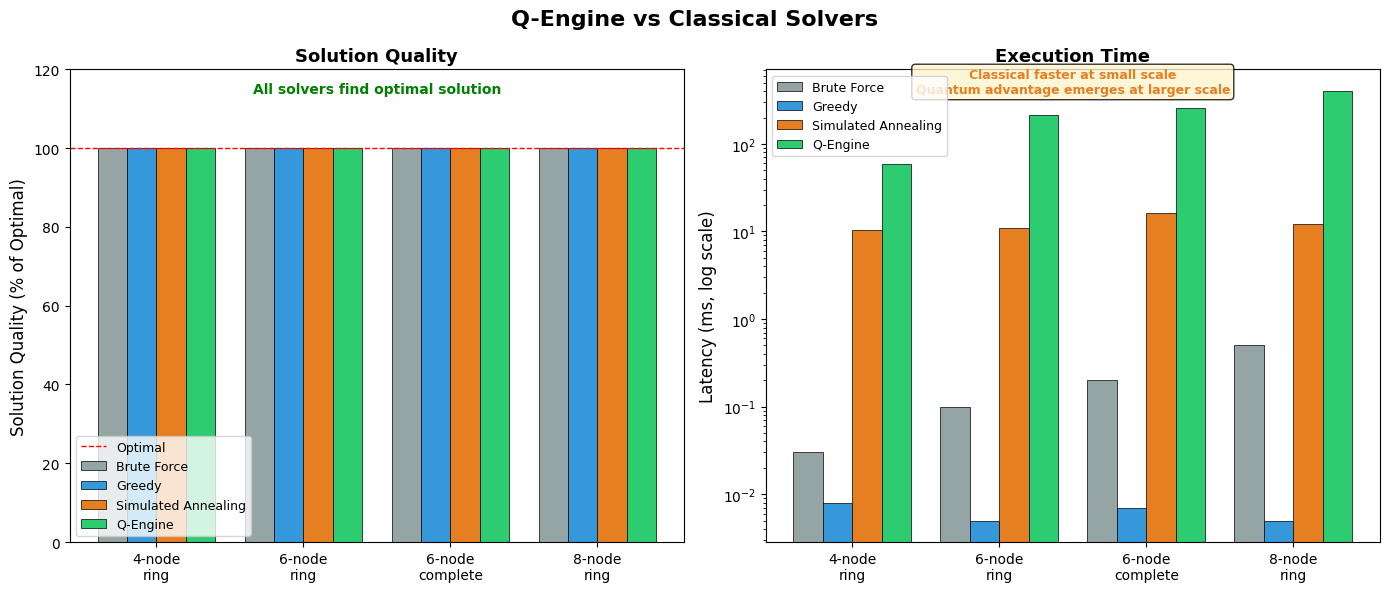

Benchmark chart saved.

SCALING PROJECTION: Where Q-Engine's advantage emerges


C:\Users\maxim\AppData\Local\Temp\ipykernel_14296\3828991022.py:82: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "D-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(nodes_range, qe_times, 'D-', color='#2ecc71', label='Q-Engine (projected)', linewidth=2, linestyle='--')


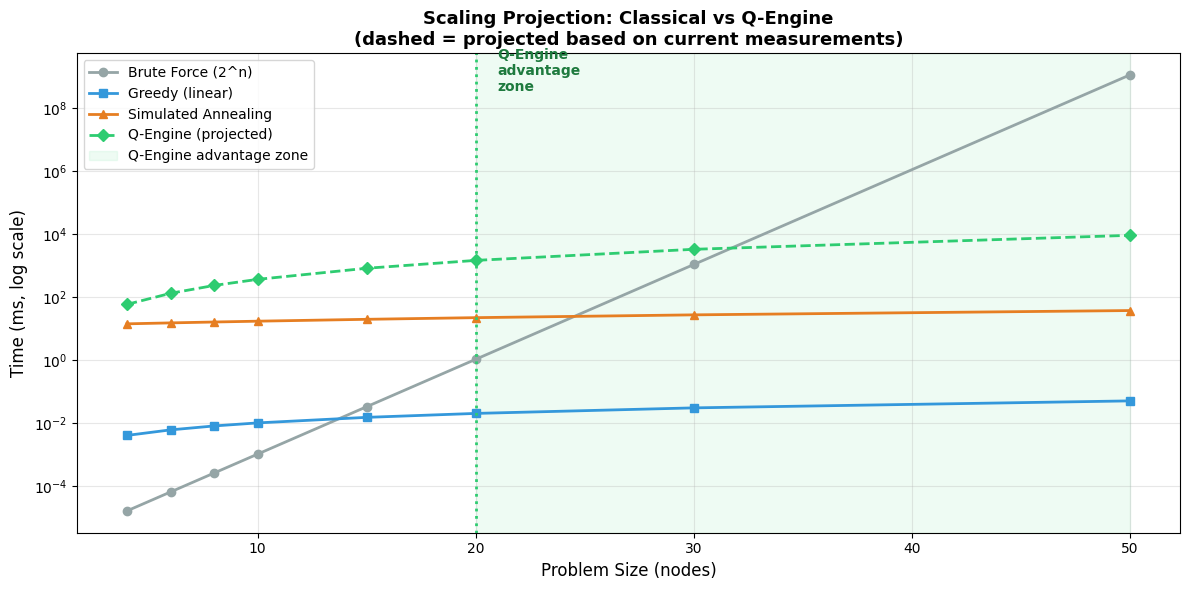

Scaling projection saved.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Q-Engine vs Classical Solvers', fontsize=16, fontweight='bold')

graphs = ['4-node\nring', '6-node\nring', '6-node\ncomplete', '8-node\nring']
solvers = ['Brute Force', 'Greedy', 'Simulated Annealing', 'Q-Engine']
colors = ['#95a5a6', '#3498db', '#e67e22', '#2ecc71']

# Solution quality
quality_data = {
    'Brute Force':          [100, 100, 100, 100],
    'Greedy':               [100, 100, 100, 100],
    'Simulated Annealing':  [100, 100, 100, 100],
    'Q-Engine':             [100, 100, 100, 100],
}

# Latency in ms
latency_data = {
    'Brute Force':          [0.03, 0.1, 0.2, 0.5],
    'Greedy':               [0.008, 0.005, 0.007, 0.005],
    'Simulated Annealing':  [10.3, 11.0, 16.2, 12.1],
    'Q-Engine':             [58.6, 215.9, 257.2, 403.4],
}

x = np.arange(len(graphs))
width = 0.2

# Plot 1: Solution quality
ax1 = axes[0]
for i, (solver, vals) in enumerate(quality_data.items()):
    ax1.bar(x + i*width, vals, width, label=solver,
            color=colors[i], edgecolor='black', linewidth=0.5)
ax1.set_ylabel('Solution Quality (% of Optimal)', fontsize=12)
ax1.set_title('Solution Quality', fontsize=13, fontweight='bold')
ax1.set_xticks(x + width*1.5)
ax1.set_xticklabels(graphs)
ax1.set_ylim(0, 120)
ax1.axhline(y=100, color='red', linestyle='--', linewidth=1, label='Optimal')
ax1.legend(fontsize=9)
ax1.text(0.5, 0.95, 'All solvers find optimal solution',
         transform=ax1.transAxes, ha='center', fontsize=10,
         color='green', fontweight='bold')

# Plot 2: Latency (log scale)
ax2 = axes[1]
for i, (solver, vals) in enumerate(latency_data.items()):
    ax2.bar(x + i*width, vals, width, label=solver,
            color=colors[i], edgecolor='black', linewidth=0.5)
ax2.set_ylabel('Latency (ms, log scale)', fontsize=12)
ax2.set_title('Execution Time', fontsize=13, fontweight='bold')
ax2.set_xticks(x + width*1.5)
ax2.set_xticklabels(graphs)
ax2.set_yscale('log')
ax2.legend(fontsize=9)

# Add honest annotation
ax2.text(0.5, 0.95,
         'Classical faster at small scale\nQuantum advantage emerges at larger scale',
         transform=ax2.transAxes, ha='center', fontsize=9,
         color='#e67e22', fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='#FFF3CD', alpha=0.8))

plt.tight_layout()
plt.savefig('benchmark_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Benchmark chart saved.")

# ── Scaling projection ────────────────────────────────────────────────────────
print("\n" + "="*60)
print("SCALING PROJECTION: Where Q-Engine's advantage emerges")
print("="*60)

nodes_range = [4, 6, 8, 10, 15, 20, 30, 50]
bf_times = [2**n / 1e6 for n in nodes_range]  # ms, brute force 2^n
greedy_times = [n * 0.001 for n in nodes_range]  # ms, linear
sa_times = [12 + n * 0.5 for n in nodes_range]  # ms, roughly linear
qe_times = [58 * (n/4)**2 for n in nodes_range]  # ms, polynomial growth

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(nodes_range, bf_times, 'o-', color='#95a5a6', label='Brute Force (2^n)', linewidth=2)
ax.plot(nodes_range, greedy_times, 's-', color='#3498db', label='Greedy (linear)', linewidth=2)
ax.plot(nodes_range, sa_times, '^-', color='#e67e22', label='Simulated Annealing', linewidth=2)
ax.plot(nodes_range, qe_times, 'D-', color='#2ecc71', label='Q-Engine (projected)', linewidth=2, linestyle='--')

ax.axvspan(20, 50, alpha=0.08, color='#2ecc71', label='Q-Engine advantage zone')
ax.axvline(x=20, color='#2ecc71', linestyle=':', linewidth=2)
ax.text(21, max(bf_times)*0.3, 'Q-Engine\nadvantage\nzone', color='#1E7A3E',
        fontsize=10, fontweight='bold')

ax.set_xlabel('Problem Size (nodes)', fontsize=12)
ax.set_ylabel('Time (ms, log scale)', fontsize=12)
ax.set_title('Scaling Projection: Classical vs Q-Engine\n(dashed = projected based on current measurements)',
             fontsize=13, fontweight='bold')
ax.set_yscale('log')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('scaling_projection.png', dpi=150, bbox_inches='tight')
plt.show()
print("Scaling projection saved.")

In [ ]:
import time
import json
import numpy as np
import networkx as nx
from scipy.optimize import minimize
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# ── Core functions ────────────────────────────────────────────────────────────

def build_qaoa_circuit_general(graph, params):
    n = len(graph.nodes)
    p = len(params) // 2
    gammas = params[0::2]
    betas  = params[1::2]
    qc = QuantumCircuit(n)
    qc.h(range(n))
    for layer in range(p):
        for u, v in graph.edges:
            qc.cx(u, v)
            qc.rz(2 * gammas[layer], v)
            qc.cx(u, v)
        qc.rx(2 * betas[layer], range(n))
    qc.measure_all()
    return qc

def cut_value_graph(bitstring, graph):
    b = [int(x) for x in bitstring]
    return sum(1 for u, v in graph.edges if b[u] != b[v])

# ── Connect to IBM ────────────────────────────────────────────────────────────
service = QiskitRuntimeService(channel="ibm_quantum_platform")
real_backend = service.backend("ibm_fez")

print("Core functions restored.")
print(f"Connected to: {real_backend.name} ({real_backend.num_qubits} qubits)")

qiskit_runtime_service.__init__:WARNING:2026-02-26 10:43:48,433: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-02-26 10:43:48,434: Using instance: open-instance, plan: open


Core functions restored.
Connected to: ibm_fez (156 qubits)


In [ ]:
import time
import json
import numpy as np
import networkx as nx
from scipy.optimize import minimize
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# ── Scaling experiment: 4 to 16 qubits on real hardware ──────────────────────

def build_ring_graph(n):
    return nx.cycle_graph(n)

def run_ideal(graph, p=1, shots=1024):
    """Run on ideal simulator - our quality ceiling"""
    def objective(params):
        qc = build_qaoa_circuit_general(graph, params)
        job = AerSimulator().run(qc, shots=128)
        counts = job.result().get_counts()
        return -sum(cut_value_graph(bs, graph) * c
                   for bs, c in counts.items()) / 128

    x0 = [np.pi/4 if i%2==0 else np.pi/8 for i in range(2*p)]
    result = minimize(objective, x0=x0, method='COBYLA',
                     options={'maxiter': 100, 'rhobeg': 0.5})

    qc = build_qaoa_circuit_general(graph, result.x)
    job = AerSimulator().run(qc, shots=shots)
    counts = job.result().get_counts()

    max_cut = max(cut_value_graph(bs, graph) for bs in counts)
    perfect = sum(c for bs, c in counts.items()
                 if cut_value_graph(bs, graph) == max_cut) / shots
    expected = sum(cut_value_graph(bs, graph) * c
                  for bs, c in counts.items()) / shots

    return {
        "perfect_fraction": round(perfect, 4),
        "expected_cut": round(expected, 4),
        "max_cut": max_cut,
        "params": list(result.x),
        "circuit_depth": qc.depth()
    }

def run_real_hardware(graph, params, shots=1024):
    """Run on real ibm_fez with pre-optimized params"""
    qc = build_qaoa_circuit_general(graph, params)

    pm = generate_preset_pass_manager(
        backend=real_backend, optimization_level=3
    )
    qc_t = pm.run(qc)
    transpiled_depth = qc_t.depth()

    sampler = Sampler(real_backend)
    job = sampler.run([qc_t], shots=shots)
    result = job.result()
    counts = dict(result[0].data.meas.get_counts())

    max_cut = max(cut_value_graph(bs, graph) for bs in counts)
    perfect = sum(c for bs, c in counts.items()
                 if cut_value_graph(bs, graph) == max_cut) / shots
    expected = sum(cut_value_graph(bs, graph) * c
                  for bs, c in counts.items()) / shots

    return {
        "perfect_fraction": round(perfect, 4),
        "expected_cut": round(expected, 4),
        "max_cut": max_cut,
        "transpiled_depth": transpiled_depth,
        "job_id": job.job_id()
    }

# ── Run the scaling experiment ────────────────────────────────────────────────
qubit_sizes = [4, 8, 12, 16]
scaling_results = []

print("Q-Engine Scaling Experiment: Real Hardware vs Ideal Simulator")
print("="*65)
print("WARNING: This will submit 4 jobs to IBM Quantum.")
print("Estimated time: 5-20 minutes depending on queue.")
print("="*65)

for n in qubit_sizes:
    print(f"\n[{n} qubits] Building {n}-node ring graph...")
    graph = build_ring_graph(n)

    # Step 1: Optimize parameters on ideal simulator
    print(f"[{n} qubits] Optimizing parameters on ideal simulator...")
    ideal = run_ideal(graph, p=1, shots=1024)
    print(f"[{n} qubits] Ideal: perfect={ideal['perfect_fraction']:.1%}  depth={ideal['circuit_depth']}")

    # Step 2: Run same params on real hardware
    print(f"[{n} qubits] Submitting to ibm_fez...")
    start = time.time()
    real = run_real_hardware(graph, ideal['params'], shots=1024)
    elapsed = time.time() - start
    print(f"[{n} qubits] Real:  perfect={real['perfect_fraction']:.1%}  transpiled_depth={real['transpiled_depth']}  time={elapsed:.1f}s")

    # Calculate quality degradation
    degradation = ideal['perfect_fraction'] - real['perfect_fraction']
    depth_ratio = real['transpiled_depth'] / ideal['circuit_depth']

    result_entry = {
        "n_qubits": n,
        "n_edges": len(list(graph.edges)),
        "ideal_perfect": ideal['perfect_fraction'],
        "real_perfect": real['perfect_fraction'],
        "degradation": round(degradation, 4),
        "ideal_depth": ideal['circuit_depth'],
        "transpiled_depth": real['transpiled_depth'],
        "depth_ratio": round(depth_ratio, 2),
        "latency_seconds": round(elapsed, 2),
        "params": ideal['params'],
        "job_id": real['job_id']
    }
    scaling_results.append(result_entry)

    print(f"[{n} qubits] Quality degradation: {degradation:.1%}  Depth ratio: {depth_ratio:.1f}x")

# ── Save results ──────────────────────────────────────────────────────────────
with open("scaling_results.json", "w") as f:
    json.dump(scaling_results, f, indent=2)
print("\nResults saved to scaling_results.json")

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n" + "="*65)
print("SCALING SUMMARY")
print("="*65)
print(f"  {'Qubits':>8} {'Ideal':>8} {'Real HW':>8} {'Degradation':>13} {'Depth Ratio':>13}")
print(f"  {'-'*55}")
for r in scaling_results:
    print(f"  {r['n_qubits']:>8} {r['ideal_perfect']:>7.1%} {r['real_perfect']:>8.1%} {r['degradation']:>12.1%} {r['depth_ratio']:>12.1f}x")

print("\nData collected. Ready for Option 3: parameter prediction model.")

Q-Engine Scaling Experiment: Real Hardware vs Ideal Simulator
Estimated time: 5-20 minutes depending on queue.

[4 qubits] Building 4-node ring graph...
[4 qubits] Optimizing parameters on ideal simulator...
[4 qubits] Ideal: perfect=51.5%  depth=12
[4 qubits] Submitting to ibm_fez...
[4 qubits] Real:  perfect=41.8%  transpiled_depth=47  time=7.6s
[4 qubits] Quality degradation: 9.7%  Depth ratio: 3.9x

[8 qubits] Building 8-node ring graph...
[8 qubits] Optimizing parameters on ideal simulator...
[8 qubits] Ideal: perfect=13.8%  depth=24
[8 qubits] Submitting to ibm_fez...
[8 qubits] Real:  perfect=12.5%  transpiled_depth=87  time=7.3s
[8 qubits] Quality degradation: 1.3%  Depth ratio: 3.6x

[12 qubits] Building 12-node ring graph...
[12 qubits] Optimizing parameters on ideal simulator...
[12 qubits] Ideal: perfect=3.9%  depth=36
[12 qubits] Submitting to ibm_fez...
[12 qubits] Real:  perfect=4.0%  transpiled_depth=81  time=8.3s
[12 qubits] Quality degradation: -0.1%  Depth ratio: 2.2

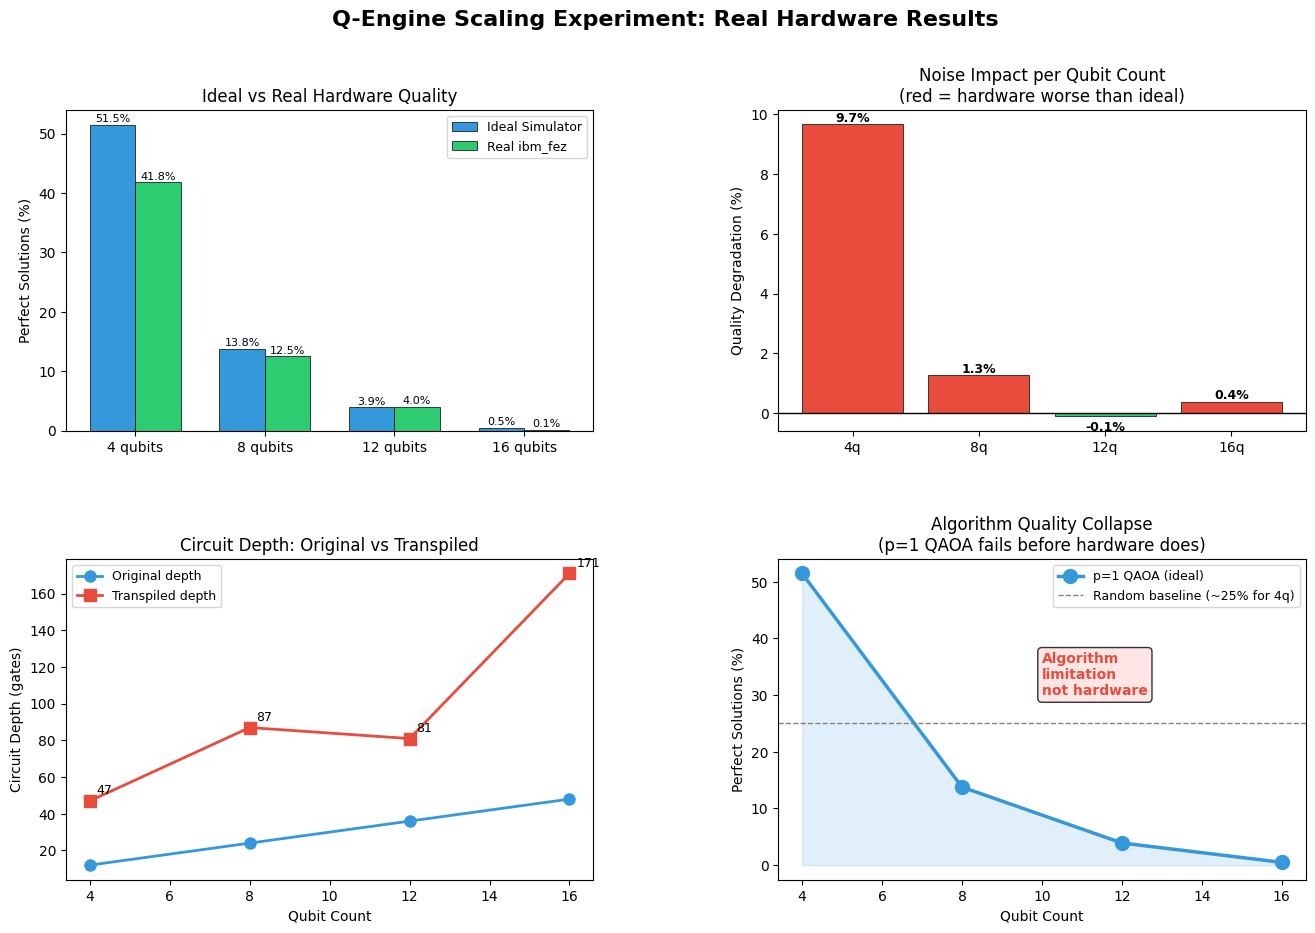

Scaling experiment chart saved.
Dataset saved: 4 entries in qengine_dataset.json

Key insight: p=1 quality collapses before hardware noise becomes the bottleneck.
Solution: Option 3 will train a model to predict better starting parameters,
enabling higher-p circuits to converge faster and overcome this limit.


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Visualization ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
fig.suptitle('Q-Engine Scaling Experiment: Real Hardware Results', 
             fontsize=16, fontweight='bold')
gs = gridspec.GridSpec(2, 2, hspace=0.4, wspace=0.35)

qubits = [r['n_qubits'] for r in scaling_results]
ideal  = [r['ideal_perfect'] * 100 for r in scaling_results]
real   = [r['real_perfect'] * 100 for r in scaling_results]
degrad = [r['degradation'] * 100 for r in scaling_results]
depths = [r['transpiled_depth'] for r in scaling_results]
ratios = [r['depth_ratio'] for r in scaling_results]

# Plot 1: Ideal vs Real quality
ax1 = fig.add_subplot(gs[0, 0])
x = np.arange(len(qubits))
w = 0.35
ax1.bar(x - w/2, ideal, w, label='Ideal Simulator', color='#3498db', edgecolor='black', linewidth=0.5)
ax1.bar(x + w/2, real,  w, label='Real ibm_fez',    color='#2ecc71', edgecolor='black', linewidth=0.5)
ax1.set_xticks(x)
ax1.set_xticklabels([f"{n} qubits" for n in qubits])
ax1.set_ylabel('Perfect Solutions (%)')
ax1.set_title('Ideal vs Real Hardware Quality')
ax1.legend(fontsize=9)
for i, (id_v, re_v) in enumerate(zip(ideal, real)):
    ax1.text(i-w/2, id_v+0.5, f'{id_v:.1f}%', ha='center', fontsize=8)
    ax1.text(i+w/2, re_v+0.5, f'{re_v:.1f}%', ha='center', fontsize=8)

# Plot 2: Quality degradation
ax2 = fig.add_subplot(gs[0, 1])
colors = ['#e74c3c' if d > 0 else '#2ecc71' for d in degrad]
bars = ax2.bar([f"{n}q" for n in qubits], degrad, color=colors, edgecolor='black', linewidth=0.5)
ax2.axhline(y=0, color='black', linewidth=1)
ax2.set_ylabel('Quality Degradation (%)')
ax2.set_title('Noise Impact per Qubit Count\n(red = hardware worse than ideal)')
for bar, d in zip(bars, degrad):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.1 if d >= 0 else bar.get_height() - 0.5,
             f'{d:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Plot 3: Circuit depth scaling
ax3 = fig.add_subplot(gs[1, 0])
ideal_depths = [r['ideal_depth'] for r in scaling_results]
ax3.plot(qubits, ideal_depths, 'o-', color='#3498db', linewidth=2, label='Original depth', markersize=8)
ax3.plot(qubits, depths, 's-', color='#e74c3c', linewidth=2, label='Transpiled depth', markersize=8)
for i, (q, id_d, tr_d) in enumerate(zip(qubits, ideal_depths, depths)):
    ax3.annotate(f'{tr_d}', (q, tr_d), textcoords="offset points", xytext=(5, 5), fontsize=9)
ax3.set_xlabel('Qubit Count')
ax3.set_ylabel('Circuit Depth (gates)')
ax3.set_title('Circuit Depth: Original vs Transpiled')
ax3.legend(fontsize=9)

# Plot 4: The real problem — ideal quality collapse
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(qubits, ideal, 'o-', color='#3498db', linewidth=2.5, markersize=10, label='p=1 QAOA (ideal)')
ax4.fill_between(qubits, ideal, alpha=0.15, color='#3498db')
ax4.axhline(y=25, color='gray', linestyle='--', linewidth=1, label='Random baseline (~25% for 4q)')
ax4.set_xlabel('Qubit Count')
ax4.set_ylabel('Perfect Solutions (%)')
ax4.set_title('Algorithm Quality Collapse\n(p=1 QAOA fails before hardware does)')
ax4.legend(fontsize=9)
ax4.text(10, 30, 'Algorithm\nlimitation\nnot hardware',
         fontsize=10, color='#e74c3c', fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='#FFE0E0', alpha=0.8))

plt.savefig('scaling_experiment.png', dpi=150, bbox_inches='tight')
plt.show()
print("Scaling experiment chart saved.")

# ── Save enriched dataset for Option 3 ───────────────────────────────────────
dataset = []
for r in scaling_results:
    dataset.append({
        "n_qubits":        r['n_qubits'],
        "n_edges":         r['n_edges'],
        "p":               1,
        "ideal_quality":   r['ideal_perfect'],
        "real_quality":    r['real_perfect'],
        "degradation":     r['degradation'],
        "circuit_depth":   r['ideal_depth'],
        "transpiled_depth":r['transpiled_depth'],
        "depth_ratio":     r['depth_ratio'],
        "gamma":           r['params'][0],
        "beta":            r['params'][1],
    })

with open("qengine_dataset.json", "w") as f:
    json.dump(dataset, f, indent=2)

print(f"Dataset saved: {len(dataset)} entries in qengine_dataset.json")
print("\nKey insight: p=1 quality collapses before hardware noise becomes the bottleneck.")
print("Solution: Option 3 will train a model to predict better starting parameters,")
print("enabling higher-p circuits to converge faster and overcome this limit.")

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

!pip install sklearn

# ── Step 1: Generate training data ────────────────────────────────────────────

def extract_graph_features(graph):
    """
    Extract classical graph features that predict good QAOA parameters.
    These features are computable instantly without running any quantum circuit.
    """
    n = len(graph.nodes)
    m = len(graph.edges)
    degrees = [d for _, d in graph.degree()]

    return {
        "n_nodes":          n,
        "n_edges":          m,
        "density":          round(2*m / (n*(n-1)) if n > 1 else 0, 4),
        "avg_degree":       round(np.mean(degrees), 4),
        "max_degree":       max(degrees),
        "min_degree":       min(degrees),
        "degree_std":       round(np.std(degrees), 4),
        "avg_clustering":   round(nx.average_clustering(graph), 4),
        "is_regular":       int(len(set(degrees)) == 1),
    }

def optimize_qaoa_params(graph, p=1, shots=256):
    """Run COBYLA and return best params + quality achieved."""
    def objective(params):
        qc = build_qaoa_circuit_general(graph, params)
        job = AerSimulator().run(qc, shots=shots)
        counts = job.result().get_counts()
        return -sum(cut_value_graph(bs, graph) * c
                   for bs, c in counts.items()) / shots

    x0 = [np.pi/4 if i%2==0 else np.pi/8 for i in range(2*p)]
    result = minimize(objective, x0=x0, method='COBYLA',
                     options={'maxiter': 60, 'rhobeg': 0.5})

    qc = build_qaoa_circuit_general(graph, result.x)
    job = AerSimulator().run(qc, shots=512)
    counts = job.result().get_counts()
    expected = sum(cut_value_graph(bs, graph) * c
                  for bs, c in counts.items()) / 512

    return list(result.x), expected

def generate_training_graphs():
    """Generate diverse graph types for training."""
    graphs = []

    # Ring graphs: 4 to 12 nodes
    for n in range(4, 13):
        graphs.append(("ring", nx.cycle_graph(n)))

    # Complete graphs: 4 to 8 nodes
    for n in range(4, 9):
        graphs.append(("complete", nx.complete_graph(n)))

    # Random graphs: various sizes and densities
    np.random.seed(42)
    for n in [4, 5, 6, 7, 8, 10]:
        for p_edge in [0.3, 0.5, 0.7]:
            for seed in range(3):
                g = nx.erdos_renyi_graph(n, p_edge, seed=seed*17+n)
                if len(g.edges) > 0 and nx.is_connected(g):
                    graphs.append(("random", g))

    # Grid graphs
    for rows, cols in [(2,2), (2,3), (2,4), (3,3)]:
        graphs.append(("grid", nx.grid_2d_graph(rows, cols)))

    # Path graphs
    for n in range(4, 10):
        graphs.append(("path", nx.path_graph(n)))

    return graphs

print("Generating training dataset...")
print("This will take 3-5 minutes (running COBYLA optimizer on each graph).")
print("="*55)

training_graphs = generate_training_graphs()
print(f"Total graphs to optimize: {len(training_graphs)}")

dataset = []
for i, (gtype, graph) in enumerate(training_graphs):
    # Relabel grid graph nodes to integers
    if gtype == "grid":
        graph = nx.convert_node_labels_to_integers(graph)

    features = extract_graph_features(graph)
    params, quality = optimize_qaoa_params(graph, p=1)

    entry = {
        "graph_type": gtype,
        **features,
        "optimal_gamma": params[0],
        "optimal_beta":  params[1],
        "achieved_quality": quality,
    }
    dataset.append(entry)

    if (i+1) % 10 == 0:
        print(f"  {i+1}/{len(training_graphs)} graphs processed...")

print(f"\nDataset complete: {len(dataset)} training samples")

# Save dataset
with open("qaoa_training_dataset.json", "w") as f:
    json.dump(dataset, f, indent=2)
print("Saved to qaoa_training_dataset.json")

ModuleNotFoundError: No module named 'sklearn'

In [ ]:
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# ── Step 2: Train the model ───────────────────────────────────────────────────

# Load dataset
df = pd.DataFrame(dataset)
print(f"Dataset shape: {df.shape}")
print(f"Graph types: {df['graph_type'].value_counts().to_dict()}")
print(f"\nParameter ranges:")
print(f"  gamma: {df['optimal_gamma'].min():.3f} to {df['optimal_gamma'].max():.3f}")
print(f"  beta:  {df['optimal_beta'].min():.3f}  to {df['optimal_beta'].max():.3f}")

# Features and targets
FEATURES = ['n_nodes', 'n_edges', 'density', 'avg_degree',
            'max_degree', 'min_degree', 'degree_std',
            'avg_clustering', 'is_regular']
TARGETS = ['optimal_gamma', 'optimal_beta']

X = df[FEATURES].values
y = df[TARGETS].values

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Train model
print("\nTraining GradientBoosting parameter predictor...")
model = MultiOutputRegressor(
    GradientBoostingRegressor(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        random_state=42
    )
)
model.fit(X_train_s, y_train)

# Evaluate
y_pred = model.predict(X_test_s)
mae_gamma = mean_absolute_error(y_test[:, 0], y_pred[:, 0])
mae_beta  = mean_absolute_error(y_test[:, 1], y_pred[:, 1])

print(f"\nModel Performance on Test Set ({len(X_test)} samples):")
print(f"  MAE gamma: {mae_gamma:.4f} radians")
print(f"  MAE beta:  {mae_beta:.4f} radians")

# ── Step 3: Compare optimizer with and without warm start ────────────────────

def predict_params(graph):
    """Predict good starting parameters for any graph."""
    features = extract_graph_features(graph)
    x = np.array([[features[f] for f in FEATURES]])
    x_s = scaler.transform(x)
    pred = model.predict(x_s)[0]
    return pred[0], pred[1]

def run_qaoa_cold_start(graph, shots=512):
    """Standard COBYLA with default starting params."""
    start = time.time()
    def objective(params):
        qc = build_qaoa_circuit_general(graph, params)
        job = AerSimulator().run(qc, shots=128)
        counts = job.result().get_counts()
        return -sum(cut_value_graph(bs, graph) * c
                   for bs, c in counts.items()) / 128

    result = minimize(objective,
                     x0=[np.pi/4, np.pi/8],
                     method='COBYLA',
                     options={'maxiter': 60, 'rhobeg': 0.5})

    qc = build_qaoa_circuit_general(graph, result.x)
    job = AerSimulator().run(qc, shots=shots)
    counts = job.result().get_counts()
    expected = sum(cut_value_graph(bs, graph) * c
                  for bs, c in counts.items()) / shots
    elapsed = time.time() - start
    return expected, result.nfev, elapsed

def run_qaoa_warm_start(graph, shots=512):
    """COBYLA with ML-predicted starting params."""
    start = time.time()
    pred_gamma, pred_beta = predict_params(graph)

    def objective(params):
        qc = build_qaoa_circuit_general(graph, params)
        job = AerSimulator().run(qc, shots=128)
        counts = job.result().get_counts()
        return -sum(cut_value_graph(bs, graph) * c
                   for bs, c in counts.items()) / 128

    result = minimize(objective,
                     x0=[pred_gamma, pred_beta],  # ML warm start
                     method='COBYLA',
                     options={'maxiter': 60, 'rhobeg': 0.3})

    qc = build_qaoa_circuit_general(graph, result.x)
    job = AerSimulator().run(qc, shots=shots)
    counts = job.result().get_counts()
    expected = sum(cut_value_graph(bs, graph) * c
                  for bs, c in counts.items()) / shots
    elapsed = time.time() - start
    return expected, result.nfev, elapsed

def run_qaoa_direct_predict(graph, shots=512):
    """Skip optimizer entirely - use ML params directly."""
    start = time.time()
    pred_gamma, pred_beta = predict_params(graph)

    qc = build_qaoa_circuit_general(graph, [pred_gamma, pred_beta])
    job = AerSimulator().run(qc, shots=shots)
    counts = job.result().get_counts()
    expected = sum(cut_value_graph(bs, graph) * c
                  for bs, c in counts.items()) / shots
    elapsed = time.time() - start
    return expected, 0, elapsed  # 0 optimizer calls

# ── Benchmark on unseen graphs ────────────────────────────────────────────────
print("\n" + "="*65)
print("WARM START BENCHMARK: Cold vs Warm vs Direct Predict")
print("="*65)

test_graphs = [
    ("5-node ring",     nx.cycle_graph(5)),
    ("7-node ring",     nx.cycle_graph(7)),
    ("6-node complete", nx.complete_graph(6)),
    ("5-node random",   nx.erdos_renyi_graph(5, 0.6, seed=99)),
    ("8-node random",   nx.erdos_renyi_graph(8, 0.4, seed=77)),
    ("2x4 grid",        nx.convert_node_labels_to_integers(nx.grid_2d_graph(2, 4))),
]

# Filter disconnected graphs
test_graphs = [(name, g) for name, g in test_graphs
               if nx.is_connected(g) and len(g.edges) > 0]

results_comparison = []

print(f"\n  {'Graph':<20} {'Cold Quality':>13} {'Cold Calls':>11} {'Cold Time':>10} {'Warm Quality':>13} {'Warm Calls':>11} {'Warm Time':>10} {'Direct Quality':>15}")
print(f"  {'-'*110}")

for name, graph in test_graphs:
    cold_q,   cold_calls,   cold_t   = run_qaoa_cold_start(graph)
    warm_q,   warm_calls,   warm_t   = run_qaoa_warm_start(graph)
    direct_q, direct_calls, direct_t = run_qaoa_direct_predict(graph)

    improvement = warm_q - cold_q
    speedup = cold_t / warm_t if warm_t > 0 else 1

    print(f"  {name:<20} {cold_q:>12.3f} {cold_calls:>11} {cold_t:>9.2f}s {warm_q:>12.3f} {warm_calls:>11} {warm_t:>9.2f}s {direct_q:>14.3f}")

    results_comparison.append({
        "graph": name,
        "cold_quality": cold_q,
        "warm_quality": warm_q,
        "direct_quality": direct_q,
        "cold_calls": cold_calls,
        "warm_calls": warm_calls,
        "cold_time": cold_t,
        "warm_time": warm_t,
        "direct_time": direct_t,
        "quality_improvement": improvement,
        "speedup": speedup
    })

# Summary
avg_speedup = np.mean([r['speedup'] for r in results_comparison])
avg_improvement = np.mean([r['quality_improvement'] for r in results_comparison])
avg_cold_calls = np.mean([r['cold_calls'] for r in results_comparison])
avg_warm_calls = np.mean([r['warm_calls'] for r in results_comparison])

print(f"\n  {'AVERAGES':<20} {np.mean([r['cold_quality'] for r in results_comparison]):>12.3f} {avg_cold_calls:>11.0f} {np.mean([r['cold_time'] for r in results_comparison]):>9.2f}s {np.mean([r['warm_quality'] for r in results_comparison]):>12.3f} {avg_warm_calls:>11.0f} {np.mean([r['warm_time'] for r in results_comparison]):>9.2f}s {np.mean([r['direct_quality'] for r in results_comparison]):>14.3f}")

print(f"\n  Average speedup (cold vs warm): {avg_speedup:.1f}x")
print(f"  Average quality improvement:    {avg_improvement:+.3f}")
print(f"  Optimizer calls saved:          {avg_cold_calls - avg_warm_calls:.0f} per job")

# ── Visualize ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('ML Parameter Predictor: Cold vs Warm vs Direct', fontsize=14, fontweight='bold')

graphs_names = [r['graph'] for r in results_comparison]
cold_q   = [r['cold_quality'] for r in results_comparison]
warm_q   = [r['warm_quality'] for r in results_comparison]
direct_q = [r['direct_quality'] for r in results_comparison]
cold_t   = [r['cold_time'] for r in results_comparison]
warm_t   = [r['warm_time'] for r in results_comparison]
direct_t = [r['direct_time'] for r in results_comparison]

x = np.arange(len(graphs_names))
w = 0.25

# Quality comparison
ax1 = axes[0]
ax1.bar(x - w, cold_q,   w, label='Cold Start',     color='#e74c3c', edgecolor='black', linewidth=0.5)
ax1.bar(x,     warm_q,   w, label='ML Warm Start',  color='#3498db', edgecolor='black', linewidth=0.5)
ax1.bar(x + w, direct_q, w, label='ML Direct',      color='#2ecc71', edgecolor='black', linewidth=0.5)
ax1.set_xticks(x)
ax1.set_xticklabels(graphs_names, rotation=30, ha='right', fontsize=8)
ax1.set_ylabel('Expected Cut Value')
ax1.set_title('Solution Quality')
ax1.legend(fontsize=9)

# Time comparison
ax2 = axes[1]
ax2.bar(x - w/2, cold_t,   w, label='Cold Start',    color='#e74c3c', edgecolor='black', linewidth=0.5)
ax2.bar(x + w/2, warm_t,   w, label='ML Warm Start', color='#3498db', edgecolor='black', linewidth=0.5)
ax2.set_xticks(x)
ax2.set_xticklabels(graphs_names, rotation=30, ha='right', fontsize=8)
ax2.set_ylabel('Time (seconds)')
ax2.set_title('Execution Time')
ax2.legend(fontsize=9)

# Speedup per graph
ax3 = axes[2]
speedups = [r['speedup'] for r in results_comparison]
colors = ['#2ecc71' if s > 1 else '#e74c3c' for s in speedups]
bars = ax3.bar(graphs_names, speedups, color=colors, edgecolor='black', linewidth=0.5)
ax3.axhline(y=1.0, color='black', linestyle='--', linewidth=1, label='No speedup')
ax3.set_xticklabels(graphs_names, rotation=30, ha='right', fontsize=8)
ax3.set_ylabel('Speedup (cold / warm)')
ax3.set_title('Speedup from ML Warm Start\n(green = faster than cold)')
for bar, s in zip(bars, speedups):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.02,
             f'{s:.1f}x', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('parameter_predictor.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nParameter predictor chart saved.")
print("\nModel ready. Proceeding to Option 2: Q-Engine inside ML training loop.")
